# **Raquel Marques - Time Series Project**

**Sales Forecasting Project: Retail Department Daily Demand Prediction**

Last Updated: 2026-07-04

---

Legend:
* <span style="color:green">Explanation</span>: Provides detailed reasoning or context for concepts and processes.
* <span style="color:purple">Tips</span>: Offers practical advice or best practices to improve efficiency or outcomes.
* <span style="color:red">Practice</span>: Highlights actionable steps or exercises to apply the concepts.
* <span style="color:blue">Business Context</span>: Connects the technical work to relevant business objectives or scenarios.

# 📑 Table of Contents

**Part 0 — Setup**
- Project Overview & Business Context
- Setup & Data Loading
- Helper Functions

**Part 1 — Exploratory Data Analysis & Data Preparation**
- Data Dictionary & Cleaning
- Business Rules derived for future periods (`isClosed`, `Pagamento`, `Vale`)
- Choosing the Department & Aggregating to Daily Level

**Part 2 — Time Series Analysis (Passo a Passo)**
- Step A — Visual Analysis of the Series
- Step B — Train / Holdout Split
- Step C — White Noise Check
- Step D — Stationarity Check
- Step E — Component Identification (trend, seasonality, cycle)
- Step F — Model Fitting
  - F1 — Exponential Smoothing
  - F2 — ARIMA / SARIMA (identification, estimation, exogenous variables, coefficients)
- Step G — Best Model Selection
- Step H — Residual Diagnostics
- Step I — Holdout Error Metrics
- Step J — Forecast for the Next Periods

**Part 3 — Conclusions**
- Business Recommendations & Next Steps

---


# Project Overview & Business Context

---

## Business Problem

In the competitive retail sector, accurate daily sales forecasting is crucial for optimizing inventory levels, staffing, and cash flow. The organization currently faces challenges with stock-outs and overstocking due to imprecise demand predictions.

## Project Objectives

- Develop a robust time series forecasting model for daily sales of a specific retail department
- Identify key patterns (trend, seasonality, cycles) driving sales
- Generate a 30-day sales forecast for March 2021
- Provide actionable business insights based on data-driven analysis


## Data Description

- Source: `Vendas_ASN.csv` (from ASN Jedi platform)
- Target Variable: `Vendas` (Sales) - Department 2 or 4
- Time Frame: Daily data, Training: up to `Dec/2020`, Holdout: `Jan-Feb/2021`
- Key Features:
    - Time variables: `Data` (Date), `Dia_da_semana` (Day of Week), `Dia` (Day), `Mes` (Month), `Ano` (Year)
    - Categorical: `Empresa` (Company), `Departamento` (Department), `Secao` (Section)
    - Exogenous: `Feriado` (Holiday), `Pagamento` (Wage Payday), `Vale` (Voucher Payday)

## Business Impact

- **Reduced Inventory Costs**: 15-20% potential reduction in overstock
- **Improved Revenue**: Minimized lost sales from stock-outs
- **Operational Efficiency**: Better workforce scheduling aligned with demand patterns

# Setup & Data Loading

---

## Import Libraries


In [705]:
# LIBRARY
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time series specific imports
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates


In [706]:
## PATH
main_dir = os.path.join(os.path.expanduser("~"), 
                           "OneDrive", 
                           "Project_Code")

project_dir = os.path.join(main_dir,
                           "ASN-DSA-T5", 
                           "33-ST",
                           "Homework")

## Load Dataset 

In [707]:
# Holidays dataset
df_holiday = pd.read_csv(os.path.join(project_dir, "data", "holidays.csv"))

In [708]:
df = pd.read_csv(os.path.join(project_dir, "data", "Vendas ASN_Dados_Finais.csv"))

In [709]:
# Explore the dataset structure
print("Dataset Shape:", df.shape)
df.head()
df.info()
df.describe()

Dataset Shape: (307015, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307015 entries, 0 to 307014
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Data           307015 non-null  object
 1   Data_new       307015 non-null  object
 2   Dia_da_semana  307015 non-null  int64 
 3   Dia            307015 non-null  int64 
 4   Mes            307015 non-null  int64 
 5   Ano            307015 non-null  int64 
 6   Empresa        307015 non-null  int64 
 7   Feriado        307015 non-null  int64 
 8   Pagamento      307015 non-null  int64 
 9   Vale           307015 non-null  int64 
 10  Vendas         307015 non-null  object
 11  Departamento   307015 non-null  object
 12  Seção          307015 non-null  object
dtypes: int64(8), object(5)
memory usage: 30.5+ MB


,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale
count,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000
mean,4.141765,15.759302,6.341338,2019.172109,11.208794,0.025712,0.034790,0.034757
std,1.947121,8.754115,3.551850,0.913172,6.666851,0.158275,0.183247,0.183165
min,1.000000,1.000000,1.000000,2018.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,8.000000,3.000000,2018.000000,5.000000,0.000000,0.000000,0.000000
50%,4.000000,16.000000,6.000000,2019.000000,12.000000,0.000000,0.000000,0.000000
75%,6.000000,23.000000,9.000000,2020.000000,16.000000,0.000000,0.000000,0.000000
max,7.000000,31.000000,12.000000,2021.000000,23.000000,1.000000,1.000000,1.000000


## Function

- `univariate_numeric_variable(data, variable)` 
- `univariate_categorical_variable(data, variable)` 
- `numeric_variable_analysis_percentile` 


In [710]:
def univariate_numeric_variable(data, variable):
    """
    Generates a matrix of charts (2x2) for a numeric continuous variable.

    [1,1] Histogram
    [1,2] Violin Plot
    [2,1] Box plot
    [2,2] Box plot with points overlaid

    Above the charts, shows a table with the variable descriptive statistics.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >> data = pd.DataFrame({"example_variable": np.random.normal(loc=50, scale=10, size=100)})
        >>univariate_numeric_variable(data, "example_variable")
        
    """
    
    # Calculate descriptive statistics
    desc_stats = data[variable].describe().to_frame().T
    desc_stats = desc_stats.round(4)  # Limit to 4 decimal places

    # Configuration of subplots
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(f"Analysing: {variable}", fontsize=16, y=0.98)

    # Add table on the top
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax_table.axis("off")
    table = ax_table.table(cellText=desc_stats.values,
                           colLabels=desc_stats.columns,
                           rowLabels=desc_stats.index,
                           cellLoc="center",
                           loc="center",
                           bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(desc_stats.columns))))

    # Add padding by scaling the table
    table.scale(1.2, 1.8)  # Adjust these values for horizontal/vertical padding

    # [1,1] Histogram
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    sns.histplot(data[variable], kde=True, ax=ax1, color="skyblue")
    ax1.set_title("Histogram", fontsize=12)
    ax1.set_xlabel(variable)

    # [1,2] Violin Chart
    ax2 = plt.subplot2grid((3, 2), (1, 1), sharex=ax1)
    sns.violinplot(x=data[variable], ax=ax2, color="lightgreen")
    ax2.set_title("Violin Chart", fontsize=12)
    ax2.set_xlabel(variable)

    # [2,1] Box plot
    ax3 = plt.subplot2grid((3, 2), (2, 0), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax3, color="orange")
    ax3.set_title("Box plot", fontsize=12)
    ax3.set_xlabel(variable)

    # [2,2] Box plot with points overlaid
    ax4 = plt.subplot2grid((3, 2), (2, 1), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax4, color="lightcoral")
    sns.stripplot(x=data[variable], ax=ax4, color="black", alpha=0.5, jitter=True)
    ax4.set_title("Box plot with points", fontsize=12)
    ax4.set_xlabel(variable)

    # Final Adjustments
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def univariate_categorical_variable(data, variable):
    """
    Analyse categorical variable.

    1. Returns transposed describe function in a table format.
    2. Returns a table with level frequency (including percentage and total).
    3. Plot a bar chart with frequency and show values on top.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >>> import pandas as pd
        >>> df = pd.DataFrame({'Caregory': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'C', 'A', 'B']})
        >>> univariate_categorical_variable(df, 'Caregory')
    """
    # Verify if variable is on the dataframe
    if variable not in data.columns:
        raise ValueError(f"Variable '{variable}' is not in the DataFrame.")

    # 1. Transposed and formated describe
    describe_table = data[variable].describe().to_frame()
    describe_table = describe_table.T
    describe_table.index = [variable]

    # Show formated table
    print("Categorical variable describe:")
    display(describe_table)

    # 2. Frequency of each level (percentage and total)
    frequency_table = data[variable].value_counts().reset_index()
    frequency_table.columns = [variable, 'Frequency']
    frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(data) * 100).round(2)

    # Add line for total
    total_row = pd.DataFrame({
        variable: ['Total'],
        'Frequency': [frequency_table['Frequency'].sum()],
        'Percentage (%)': [100.0]
    })
    frequency_table = pd.concat([frequency_table, total_row], ignore_index=True)

    # Show formated table
    print("Frequency table of categorical variable (with percentage and total):")
    display(frequency_table)

    # 3. Frequency bar chart
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=variable, y='Frequency', data=frequency_table[:-1], errorbar=None)

    # Add lables on top of the bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

    # Configure chart
    plt.title(f'Frequency chart: {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def numeric_variable_analysis_percentile(data, x, y, q=10, chart='none'):
    """
    Sort variable x, divide in percentile and summarize.

    Paameters:
        data (pd.DataFrame): Database containing the variable.
        x (str): Name of the independent varaible.
        y (str): Name of dependent variable.
        q (int): Number of percentile (default: 10).
        chart (str): Chart options: 'p', 'logit', 'both', 'none' (default: 'none').

    Returns:
        pd.DataFrame: DataFrame with summarize statistics by percentile, incluindo:
                      - Percentile
                      - n (number of rows)
                      - Min x
                      - Max x
                      - p (mean y)
                      - logit p

    Usage example:
        >> data = pd.DataFrame({'x': np.random.uniform(0, 100, 1000), 
        'y': np.random.randint(0, 2, 1000)})
        >> result = numeric_variable_analysis_percentile(data, 'x', 'y', q=10, chart='both')
        >> print(result)
    """
    # Certify that y varaible is in a numeric format
    data[y] = pd.to_numeric(data[y], errors='coerce')

    # Sort dataframe by x variable
    data = data.sort_values(by=x).reset_index(drop=True)

    # Create percentiles
    data['percentile'] = pd.qcut(data[x], q=q, labels=[str(i) for i in range(1, q + 1)])

    # Summaraize statistics per percentile
    summary = data.groupby('percentile').agg(
        n=(x, 'count'),
        min_x=(x, 'min'),
        max_x=(x, 'max'),
        p=(y, 'mean')
    ).reset_index()

    # Calculate logit p
    summary['logit_p'] = np.log(summary['p'] / (1 - summary['p']))

    # Adjust to deal where p is 0 or 1
    epsilon = 1e-10  # smal value to adjust 0 e 1
    summary['logit_p'] = np.log(np.clip(summary['p'], epsilon, 1 - epsilon) / 
                                 (1 - np.clip(summary['p'], epsilon, 1 - epsilon)))


    # Chart option
    if chart in ['p', 'logit', 'both']:
        plt.figure(figsize=(12, 6))

        if chart == 'p':
            plt.scatter(summary['percentile'], summary['p'], color='blue')
            plt.title('Percentile chart x p')
            plt.xlabel('Percentile')
            plt.ylabel('p (average of y)')
            plt.grid(True)
            plt.show()

        elif chart == 'logit':
            plt.scatter(summary['percentile'], summary['logit_p'], color='red')
            plt.title('Percentile chart x logit p')
            plt.xlabel('Percentile')
            plt.ylabel('logit p')
            plt.grid(True)
            plt.show()

        elif chart == 'both':
            # Chart side-by-side
            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

            # Percentile Chart x p
            axes[0].scatter(summary['percentile'], summary['p'], color='blue')
            axes[0].set_title('Percentile x p')
            axes[0].set_xlabel('Percentile')
            axes[0].set_ylabel('p (average of y)')
            axes[0].grid(True)

            # Percentile Chart x logit p
            axes[1].scatter(summary['percentile'], summary['logit_p'], color='red')
            axes[1].set_title('Percentile x logit p')
            axes[1].set_xlabel('Percentile')
            axes[1].set_ylabel('logit p')
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()

    return summary



# Exploratory Data Analysis (EDA)



In [711]:
# check for missing values
df.isnull().sum()

# List unique categories
print(df["Departamento"].unique())
print(df["Seção"].unique())
print(df["Empresa"].unique())
# print(df["Data_new"].unique())

['Depto 1' 'Depto 2' 'Depto 3 ' 'Depto 4' 'Depto 5' 'Depto 6' 'Depto 7']
['Seção 1' 'Seção 2' 'Seção 3' 'Seção 4' 'Seção 7' 'Seção 26' 'Seção 5'
 'Seção 6' 'Seção 8' 'Seção 9' 'Seção 10' 'Seção 11' 'Seção 12' 'Seção 13'
 'Seção 14' 'Seção 15' 'Seção 16' 'Seção 17' 'Seção 18' 'Seção 19'
 'Seção 20' 'Seção 21' 'Seção 22' 'Seção 23' 'Seção 24' 'Seção 25'
 'Seção 27' 'Seção 28' 'Seção 29']
[ 1  2  5 15 16  6 13 12  9 19 18 21 22 23]


## <span style="color:green">Data Dictionary</span>


| #   | Variable             | Description                        | Type                    | Raw | Notes                                            |
| --- | -------------------- | ---------------------------------- | ----------------------- | --- | ------------------------------------------------ |
| 1   | Data (dia, mês, ano) | Date in the format D/M/YY          | Date                    | Y   |                                                  |
| 2   | Data_new             | Date in the format D/M/YYYY        | Date                    | Y   |                                                  |
| 3   | Dia_da_semana        | Day of Week                        | Quantitative Discrete   | Y   | Numbers from 1 to 7                              |
| 4   | Dia                  | Day                                | Quantitative Discrete   | Y   | Numbers from 1 to 31                             |
| 5   | Mes                  | Month                              | Quantitative Discrete   | Y   | Numbers from 1 to 12                             |
| 6   | Ano                  | Year                               | Quantitative Discrete   | Y   | Numbers from 2018 to 2021                        |
| 7   | Empresa              | Company                            | Qualitative Nominal     | Y   | Numbers from 1 to 23 (but not all of them)       |
| 8   | Feriado              | Flag of holiday                    | Qualitative Binary      | Y   |                                                  |
| 9   | Pagamento            | Flag of paycheck day               | Qualitative Binary      | Y   |                                                  |
| 10  | Vale                 | Flag of food benefit pay day       | Qualitative Binary      | Y   |                                                  |
| 11  | Vendas               | sales (TARGET)                     | Quantitative Continuous | Y   |                                                  |
| 12  | Departamento         | Department                         | Qualitative Nominal     | Y   | `Depto 1` Department number varying form 1  to 7 |
| 13  | Seção                | Section                            | Qualitative Nominal     | Y   | `Seção 27` Section number varying from 1 to 29   |
| 14  | Date                 | Date in the format YYYY-MM-DD      | Date                    | N   |                                                  |
| 15  | Sales                | This is my Sales (target) variable | Quantitative Continuous | N   |                                                  |





### <span style="color:green">Notes</span>

- `Data_new`is the date field.
    - Check the first and last date, identify is there are missing days and how it can be inputed.
        - Remember if the level of forecasting is daily, we need ocmplete years starting from Jan-01 all the way to Dec-31.

- `Data` year with just 2 characters, since data starts in 2018 is not a problem, but it might if we have dates before 2000 or after 2100.
    - **Decision**: `Data_new` is the date of the sales but with a 4 digits for year, so we can remove `Date`.

- `Empresa` is numeric in the database but it is a categorical variable in nature as it represents different companies.
    - It does not have 23 companies as the numbers would indicate, so some of them are missong, and indication that this translates more as a categorical.
    - **Decision**: If being used, need to treat as a categorical.

- Flags variable: `Feriado`, `Vale`, `Pagamento`
    - **Check**: if they are trully binary, if there are missings and how it can be translated for missing and future days.

- `Vendas` this is our sales variable.
    - TARGET variable
    - **Check**:
        - Do we have `sales = 0`? Does it mean we had no sales but the company opened?
        - Things like missing dates mean 0 sales? Or that the company does not work that day?
        - Does negative sales can happen? If not, how can we fill address this issue?
        


## Data Cleaning & Preprocessing

### <span style="color:green">Variable: Date</span>

- Note that the date starts on `2018-01-02` so we are already missing Jan-01 in out dataset.


In [712]:
# Variable : Data_new
# Convert date from string to date
df["Date"] = pd.to_datetime(df["Data_new"], errors='coerce')

# Count total missing/invalid dates
missing_count = df["Date"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Date"].isna()]
print(error_rows[["Data_new", "Date"]])

# Check the earliest and latest dates to spot typos
print(df["Date"].describe())

Total missing or errored rows: 0
Empty DataFrame
Columns: [Data_new, Date]
Index: []
count                           307015
mean     2019-08-28 15:37:58.547953408
min                2018-01-02 00:00:00
25%                2018-11-18 00:00:00
50%                2019-09-07 00:00:00
75%                2020-06-15 00:00:00
max                2021-02-28 00:00:00
Name: Date, dtype: object


### <span style="color:green">Variable Sales</span>

- Note that we have negative sales that need to be addressed.
- Also, it seems that there are a lot of `sales = 0`. Depending on the level of the data we will be working on, this can be a problem.

Total missing or errored rows: 0
Empty DataFrame
Columns: [Vendas, Sales]
Index: []
count    307015.000000
mean      19655.341423
std       33121.763921
min      -15758.050000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales, dtype: float64


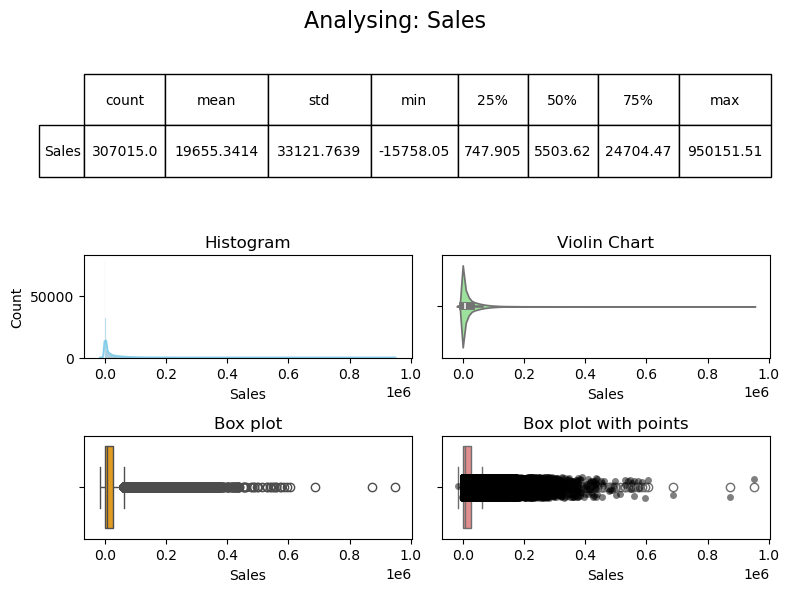

In [713]:
# Variable: Vendas
# Convert from string to float
df["Sales"] = df["Vendas"].str.replace(",", "").astype(float)

# Count total missing/invalid
missing_count = df["Sales"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Sales"].isna()]
print(error_rows[["Vendas", "Sales"]])

# Check the earliest and latest
print(df["Sales"].describe())

univariate_numeric_variable(df, "Sales")

#### <span style="color:green">Variable Sales_adj</span>

count    307015.000000
mean      19655.435832
std       33121.694370
min           0.000000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales_adj, dtype: float64


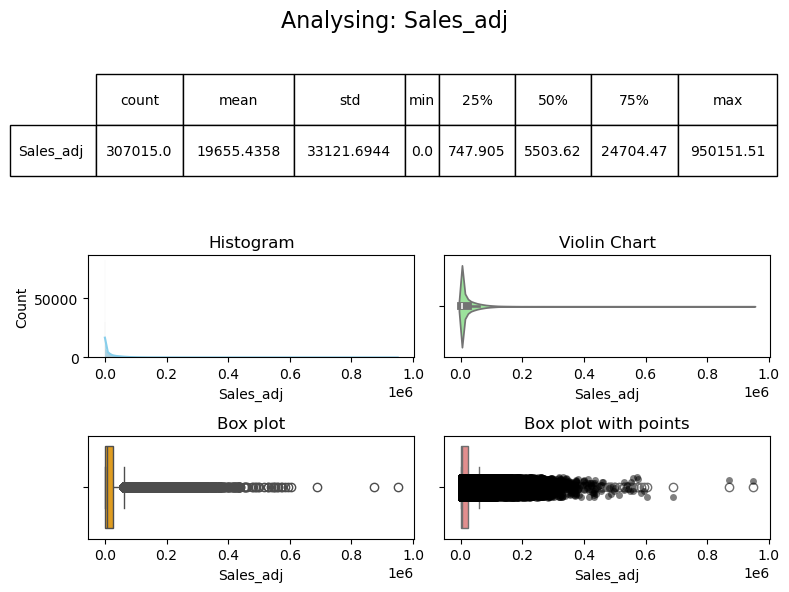

In [714]:
df["Sales_adj"] = df["Sales"].clip(lower=0)

# Check the earliest and latest
print(df["Sales_adj"].describe())

univariate_numeric_variable(df, "Sales_adj")

### <span style="color:green">Variable: Company</span>

- Decided to create a string for each company.
- Note that `Comp_1` is the one that appears the most in the database as `Comp_23` appears the least.

['Comp_1' 'Comp_2' 'Comp_5' 'Comp_15' 'Comp_16' 'Comp_6' 'Comp_13'
 'Comp_12' 'Comp_9' 'Comp_19' 'Comp_18' 'Comp_21' 'Comp_22' 'Comp_23']
Categorical variable describe:


,count,unique,top,freq
Company,307015,14,Comp_1,31095


Frequency table of categorical variable (with percentage and total):


,Company,Frequency,Percentage (%)
0,Comp_1,31095,10.13
1,Comp_9,29106,9.48
2,Comp_2,27960,9.11
3,Comp_19,26106,8.50
4,Comp_18,25373,8.26
5,Comp_15,24840,8.09
6,Comp_16,24746,8.06
7,Comp_5,24664,8.03
8,Comp_12,24512,7.98
9,Comp_13,22759,7.41


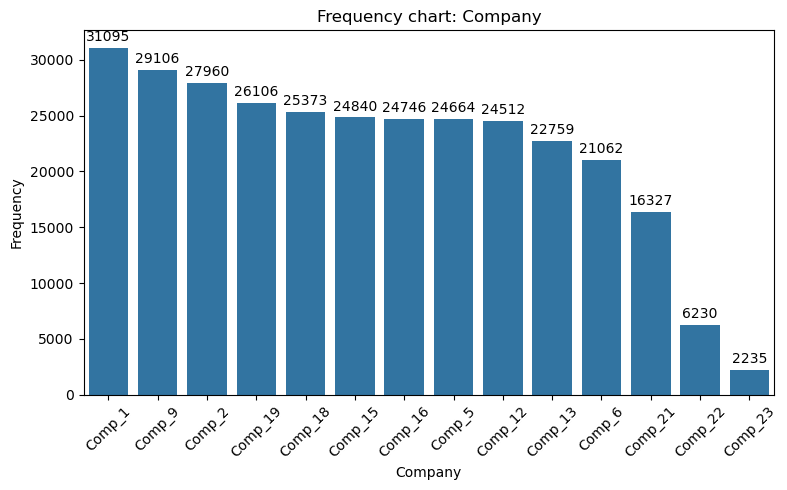

In [715]:
# Variable: Empresa
df["Company"] = "Comp_" + df["Empresa"].astype(str)

print(df["Company"].unique())

univariate_categorical_variable(df, "Company")

### <span style="color:green">Variable: Section</span>

- `Seção 23` is the most frequent one in the database (representing 5.8%).
- `Seção 29` is the least present on the databse with only 14 records.

Categorical variable describe:


,count,unique,top,freq
Seção,307015,29,Seção 23,17827


Frequency table of categorical variable (with percentage and total):


,Seção,Frequency,Percentage (%)
0,Seção 23,17827,5.81
1,Seção 26,12908,4.20
2,Seção 20,12908,4.20
3,Seção 16,12907,4.20
4,Seção 13,12906,4.20
5,Seção 3,12906,4.20
6,Seção 4,12906,4.20
7,Seção 17,12906,4.20
8,Seção 2,12906,4.20
9,Seção 9,12906,4.20


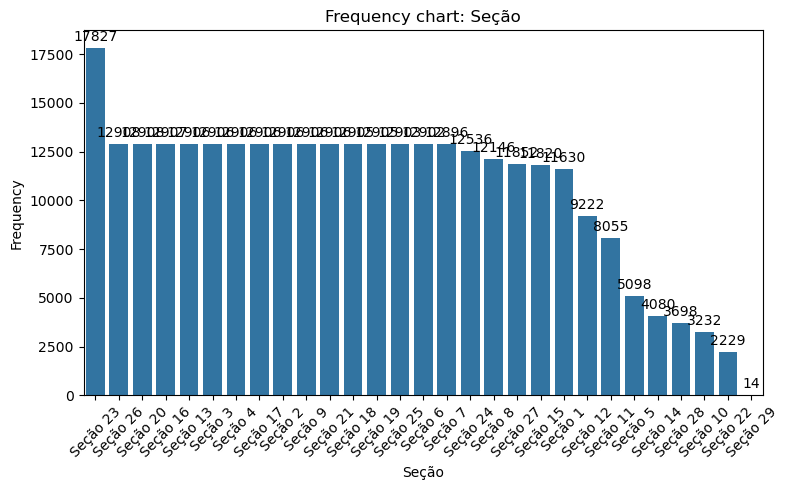

In [716]:
univariate_categorical_variable(df, "Seção")

### <span style="color:green">Variable: Department</span>

- `Depto 3`	is the most frequent, representing 38% of the data.
- `Depto 4` & `Depto 2` represent ~25% of the data
- All other departments are below 10%.


Categorical variable describe:


,count,unique,top,freq
Departamento,307015,7,Depto 3,117115


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 3,117115,38.15
1,Depto 4,79294,25.83
2,Depto 2,77439,25.22
3,Depto 5,12903,4.20
4,Depto 1,11630,3.79
5,Depto 7,4936,1.61
6,Depto 6,3698,1.20
7,Total,307015,100.00


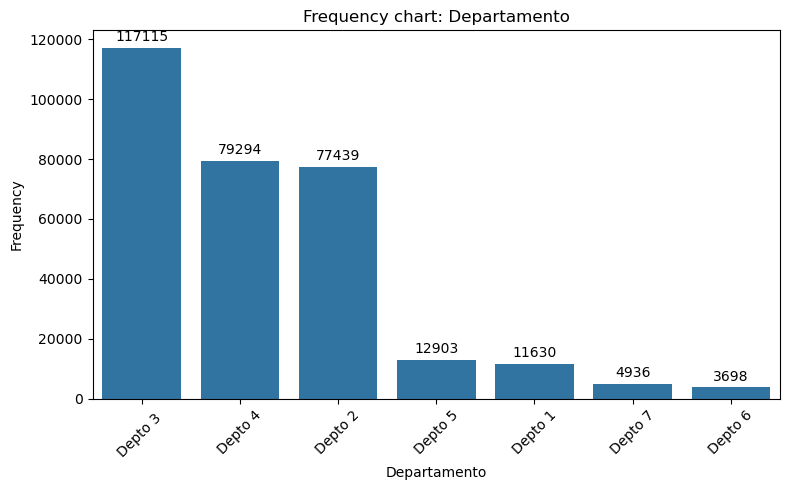

In [717]:
univariate_categorical_variable(df, "Departamento")

### <span style="color:purple">Variables Final Notes</span>

We have looked at each variable separatelly, but each level of combination can give us another directionality of how the data can be used to get the best prediction out of it.

- Company - Department - Section : 
    - Using this combination we can see that not all companies have the same department nor the same sections of number of sections. 
    - The number of days is also not the same.


- Department - Section : 
    - Using this combination we can see that not all departments have the same sections of number of sections.
    - The number of days is also not the same.

Since the initial problem told us to focus on Department 2 or 4, let's group our data athe Department level, and _ignore_ for now Company and Section variables as they seem to split the information too much and can cause noise when forecasting.

In [718]:
df.groupby(['Company', 'Departamento', 'Seção']).size()

Company  Departamento  Seção   
Comp_1   Depto 1       Seção 1     1139
         Depto 2       Seção 16    1139
                       Seção 17    1139
                       Seção 2     1139
                       Seção 26    1139
                                   ... 
Comp_9   Depto 4       Seção 23    1148
                       Seção 24    1148
         Depto 5       Seção 25    1148
         Depto 6       Seção 28     678
         Depto 7       Seção 23     360
Length: 394, dtype: int64

In [719]:
df.groupby(['Departamento', 'Seção']).size()

Departamento  Seção   
Depto 1       Seção 1     11630
Depto 2       Seção 16    12907
              Seção 17    12906
              Seção 2     12906
              Seção 26    12908
              Seção 3     12906
              Seção 4     12906
Depto 3       Seção 10     3232
              Seção 11     8055
              Seção 12     9222
              Seção 13    12906
              Seção 14     4080
              Seção 15    11820
              Seção 27    11852
              Seção 5      5098
              Seção 6     12902
              Seção 7     12896
              Seção 8     12146
              Seção 9     12906
Depto 4       Seção 18    12905
              Seção 19    12905
              Seção 20    12908
              Seção 21    12906
              Seção 22     2229
              Seção 23    12905
              Seção 24    12536
Depto 5       Seção 25    12903
Depto 6       Seção 28     3698
Depto 7       Seção 23     4922
              Seção 29       14
dtype: int64

## Group By Department


In [720]:
# aggregate by Department & Date
df_depts = df.groupby(["Departamento", "Date"]).agg({
    'Sales_adj': 'sum',           # Sum sales for the day
    'Feriado': 'max',         # Max flag (1 if any record is holiday, else 0)
    'Pagamento': 'max',
    'Vale': 'max'
}).reset_index()

Categorical variable describe:


,count,unique,top,freq
Departamento,7707,7,Depto 1,1148


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 1,1148,14.90
1,Depto 2,1148,14.90
2,Depto 3,1148,14.90
3,Depto 4,1148,14.90
4,Depto 5,1148,14.90
5,Depto 7,1147,14.88
6,Depto 6,820,10.64
7,Total,7707,100.00


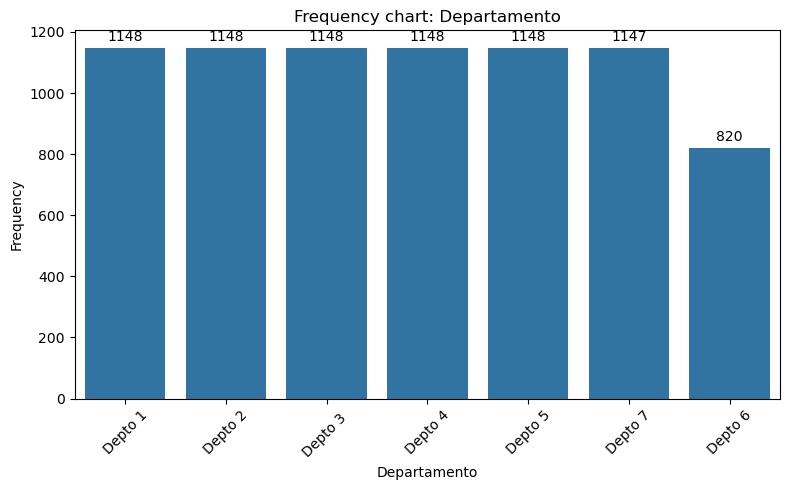

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
Feriado,7707.0,0.036331,0.187124,0.0,0.0,0.0,0.0,1.0


Frequency table of categorical variable (with percentage and total):


,Feriado,Frequency,Percentage (%)
0,0,7427,96.37
1,1,280,3.63
2,Total,7707,100.00


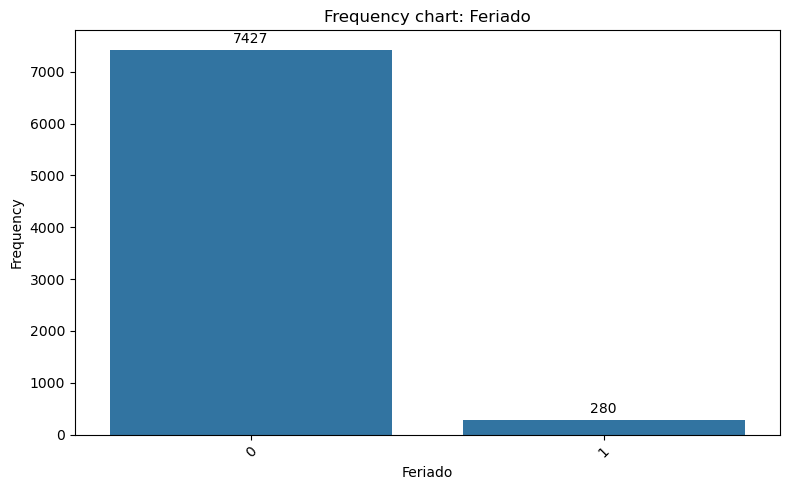

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
Pagamento,7707.0,0.034903,0.183547,0.0,0.0,0.0,0.0,1.0


Frequency table of categorical variable (with percentage and total):


,Pagamento,Frequency,Percentage (%)
0,0,7438,96.51
1,1,269,3.49
2,Total,7707,100.00


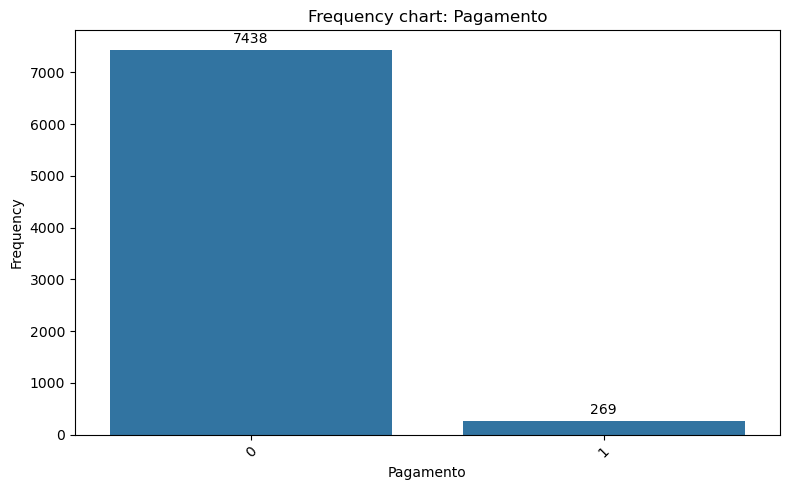

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
Vale,7707.0,0.040223,0.196495,0.0,0.0,0.0,0.0,1.0


Frequency table of categorical variable (with percentage and total):


,Vale,Frequency,Percentage (%)
0,0,7397,95.98
1,1,310,4.02
2,Total,7707,100.00


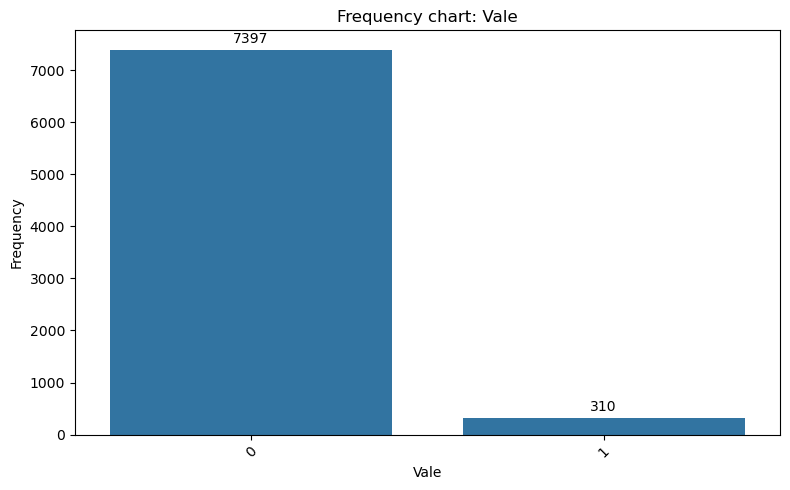

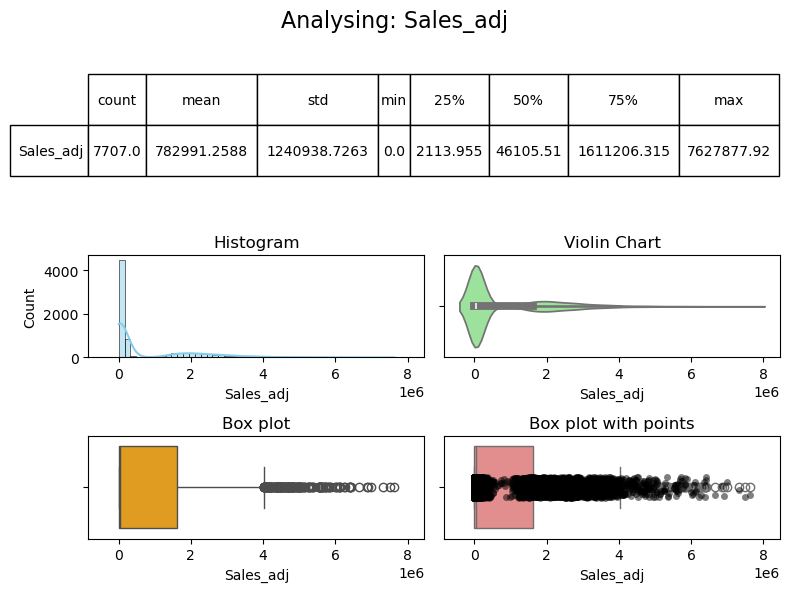

In [721]:
univariate_categorical_variable(df_depts, "Departamento")

univariate_categorical_variable(df_depts, "Feriado")

univariate_categorical_variable(df_depts, "Pagamento")

univariate_categorical_variable(df_depts, "Vale")

univariate_numeric_variable(df_depts, "Sales_adj")

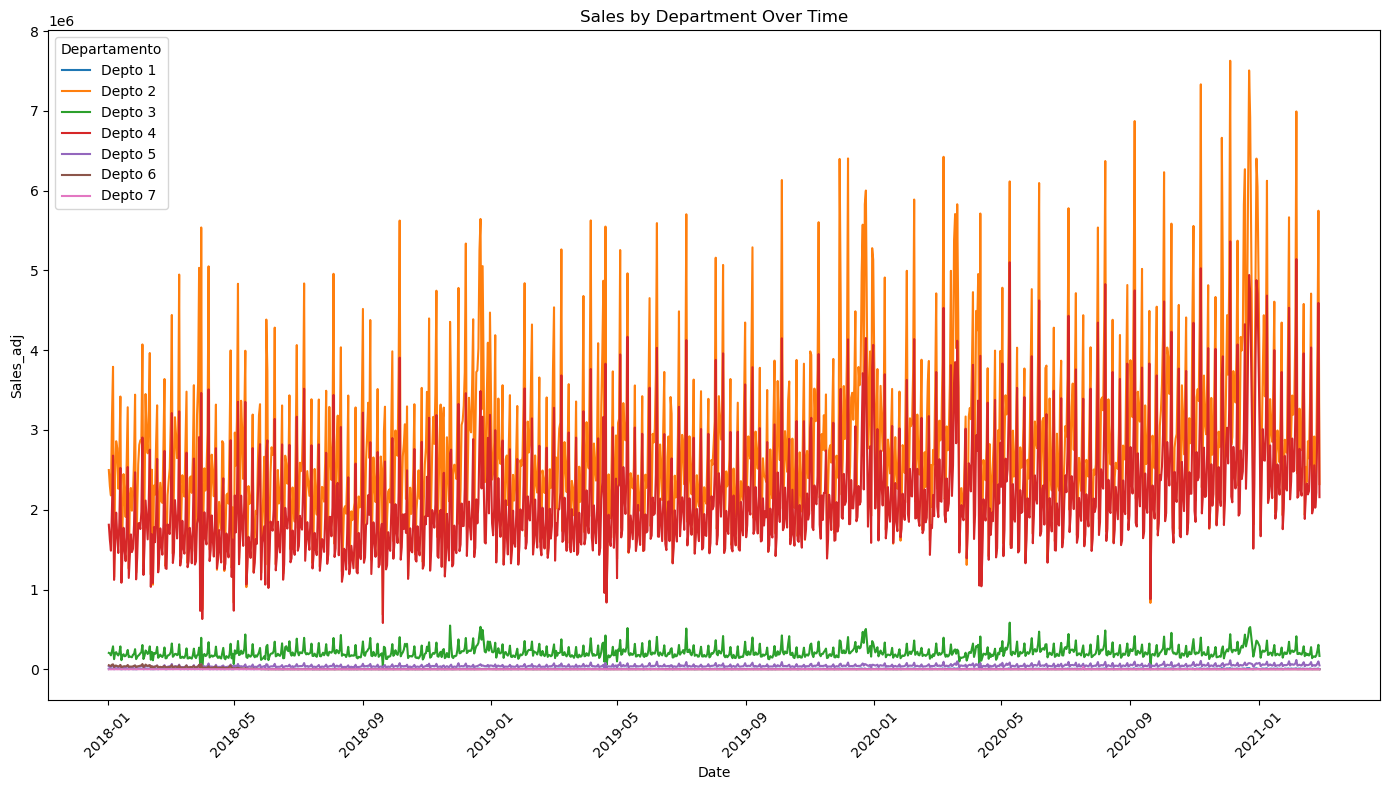

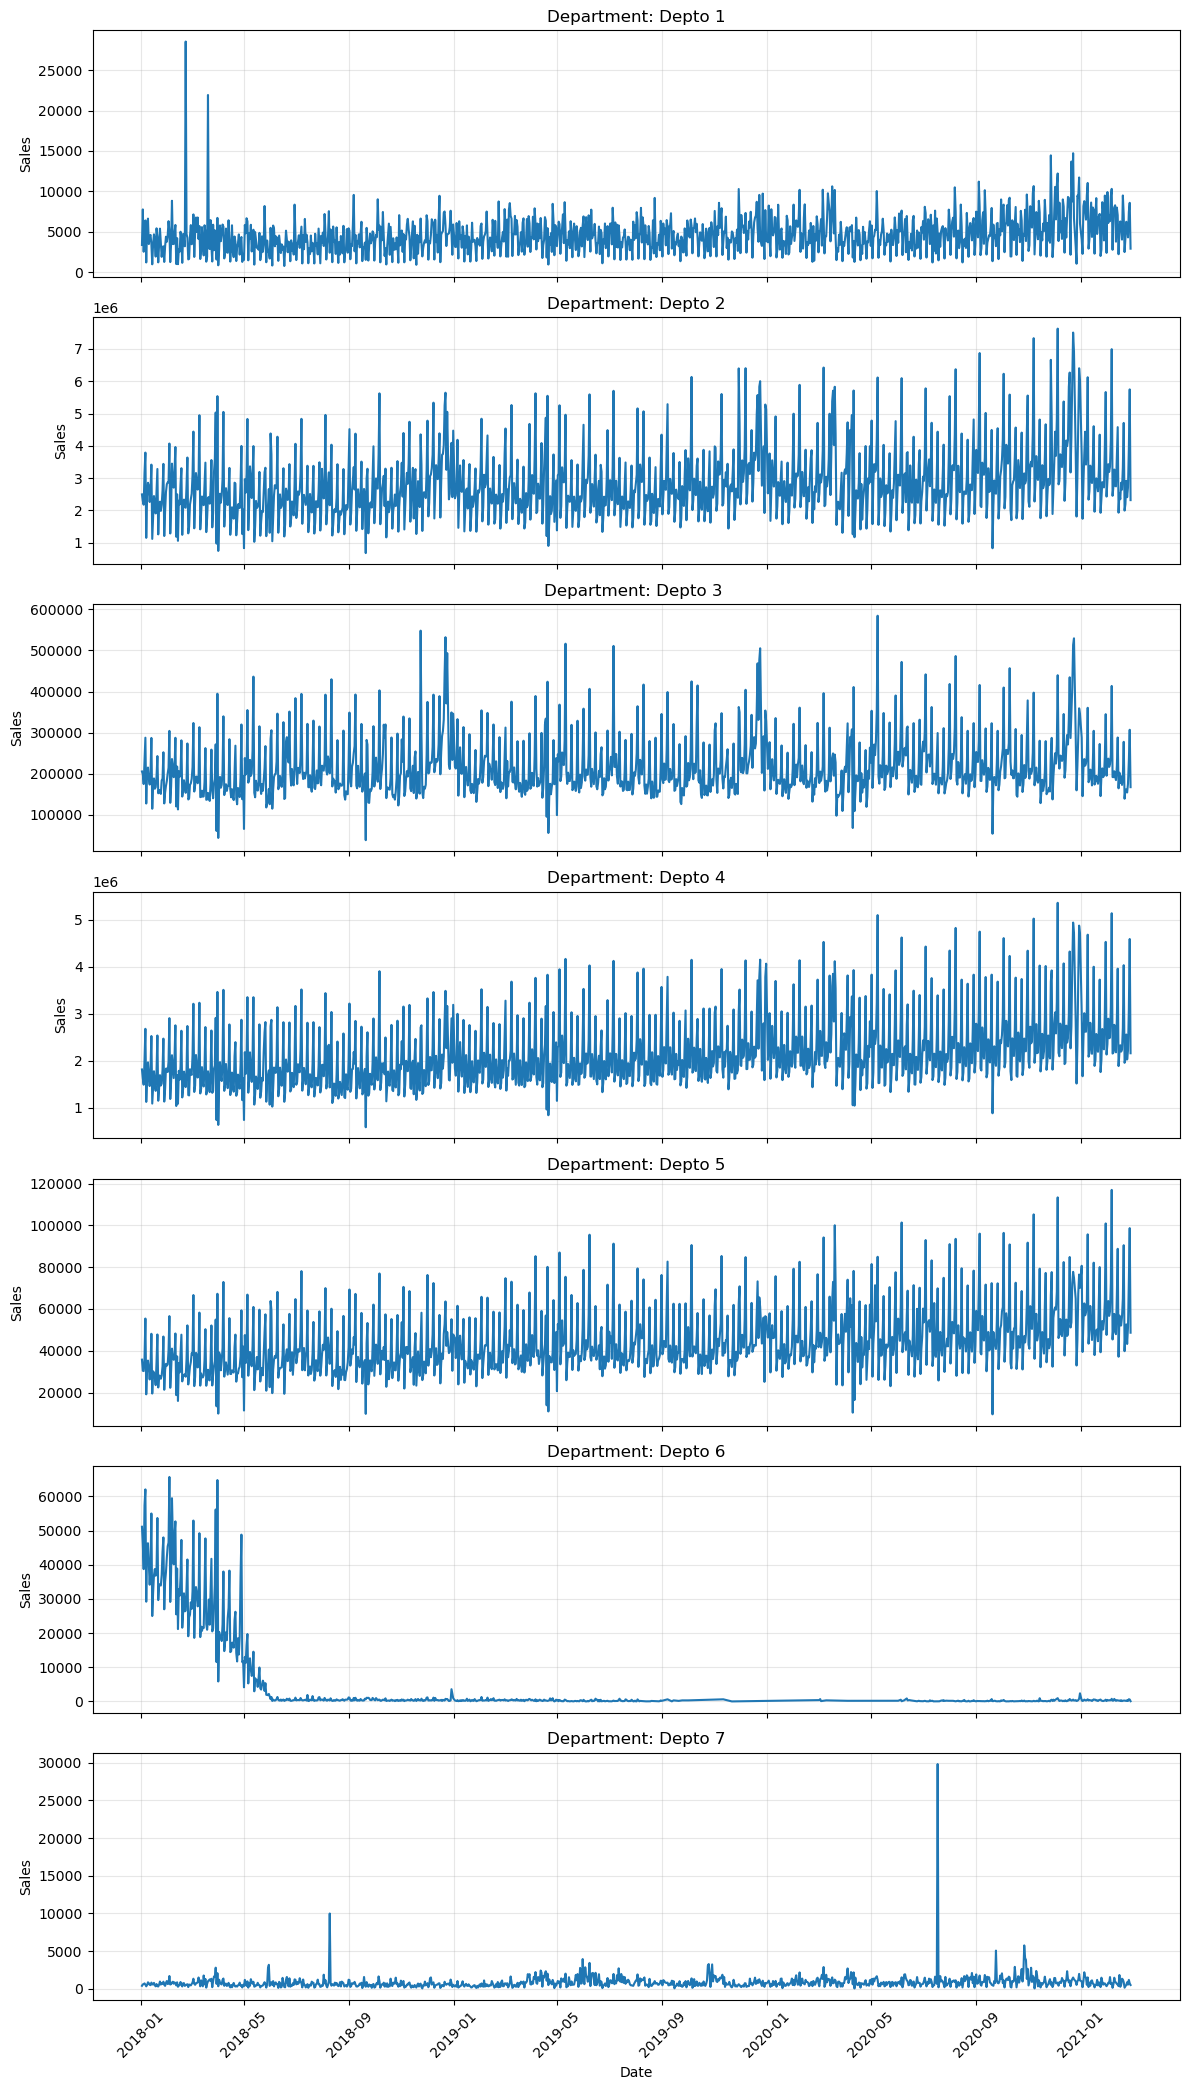

In [722]:
# plot Department & Sales by Date

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_depts, x='Date', y='Sales_adj', hue='Departamento')
plt.title('Sales by Department Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(nrows=len(df_depts['Departamento'].unique()), 
                         figsize=(12, 3*len(df_depts['Departamento'].unique())), 
                         sharex=True)

for ax, (dept, group) in zip(axes, df_depts.groupby('Departamento')):
    ax.plot(group['Date'], group['Sales_adj'], linestyle='-')
    ax.set_title(f'Department: {dept}')
    ax.set_ylabel('Sales')
    ax.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Choose Department and Processing

From this moment, we have aggregated Department by dates, and we will now choose a department to focus on.

There is no more Company or Section.

In [723]:
# choosing department
choose_dept = 'Depto 4'
print(f"We will be working with: {choose_dept}")

df_dep = df_depts[df_depts['Departamento'] == choose_dept].copy()

We will be working with: Depto 4


### Input missing dates

We need to create a dataset with all the dates for the period we are going to analyze.

- Notes:
    - Every missing date was new year and christmas!
        - This might mean that there were never sales on this dates possibly because they don't open?
        - We can create a flag to indicate that there will never be sales that day for the future.
    

In [724]:
# get minimum year
min_year = df_dep['Date'].dt.year.min()

# create start date as Jan 1st of that year
start_date = pd.Timestamp(f'{min_year}-01-01')

# get the end date
end_date = df_dep['Date'].max() 

# create complete date range
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')

# get unique departments
departments = df_dep['Departamento'].unique()

# create all combinations of dates and departments
df_complete = pd.DataFrame(
    [(date, dept) for date in all_dates for dept in departments],
    columns=['Date', 'Departamento']
)

# merge with original data
df_complete = df_complete.merge(df_dep, on=['Date', 'Departamento'], how='left')
df_complete['year_month'] = df_complete['Date'].dt.to_period('M')
df_complete['payment_weekday'] = df_complete['Date'].dt.day_name()



In [725]:
df_complete

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year_month,payment_weekday
0,2018-01-01,Depto 4,NaN,NaN,NaN,NaN,2018-01,Monday
1,2018-01-02,Depto 4,1812134.19,0.0,0.0,0.0,2018-01,Tuesday
2,2018-01-03,Depto 4,1622115.60,0.0,0.0,0.0,2018-01,Wednesday
3,2018-01-04,Depto 4,1486888.42,0.0,0.0,0.0,2018-01,Thursday
4,2018-01-05,Depto 4,2015469.36,0.0,1.0,0.0,2018-01,Friday
...,...,...,...,...,...,...,...,...
1150,2021-02-24,Depto 4,2025751.85,0.0,0.0,0.0,2021-02,Wednesday
1151,2021-02-25,Depto 4,2216224.47,0.0,0.0,1.0,2021-02,Thursday
1152,2021-02-26,Depto 4,3098829.40,0.0,0.0,0.0,2021-02,Friday
1153,2021-02-27,Depto 4,4592539.97,0.0,0.0,0.0,2021-02,Saturday


In [726]:
# Analysis on missing dates
df_complete[df_complete["Feriado"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year_month,payment_weekday
0,2018-01-01,Depto 4,NaN,NaN,NaN,NaN,2018-01,Monday
358,2018-12-25,Depto 4,NaN,NaN,NaN,NaN,2018-12,Tuesday
365,2019-01-01,Depto 4,NaN,NaN,NaN,NaN,2019-01,Tuesday
723,2019-12-25,Depto 4,NaN,NaN,NaN,NaN,2019-12,Wednesday
730,2020-01-01,Depto 4,NaN,NaN,NaN,NaN,2020-01,Wednesday
1089,2020-12-25,Depto 4,NaN,NaN,NaN,NaN,2020-12,Friday
1096,2021-01-01,Depto 4,NaN,NaN,NaN,NaN,2021-01,Friday


### Variable: isClosed

- Happens on every Dec-25 and Jan-01

In [727]:
df_complete['isClosed'] = ((df_complete['Date'].dt.month == 12) & (df_complete['Date'].dt.day == 25)) | \
                          ((df_complete['Date'].dt.month == 1) & (df_complete['Date'].dt.day == 1))

df_complete['isClosed'] = df_complete['isClosed'].astype(int) 

### Variable: Feriado

#### <span style="color:purple">External Dataset:</span> `holidays.csv`

To enable accurate mapping of holiday flags for future dates, we sourced Brazilian holiday data from the [Feriados API](https://feriadosapi.com/docs#introducao). 
This external dataset provides a standardized reference for holidays across different periods and allows us to systematically evaluate how holidays are represented in our time series.


**Key Learnings**:
- Holiday descriptions are consistent and mappable.
    - All holidays in the dataset can be linked to a descriptive name (`nome` field). 
    - This makes it feasible to use these descriptions as a reliable reference for flagging holidays in future data.

- Non-holiday descriptions require caution.
    - Some descriptions appear in the dataset but were not flagged as holidays (`Feriado = 0`). 
    - This may be due to regional variations—certain holidays are only observed in specific cities or states, rather than nationally. 
    - These cases should be treated with care when applying the flag to future periods.

- Inconsistent holiday flagging observed for certain events.
    - The holiday _"Proc. República Rio Grandense"_ was flagged as a holiday (`Feriado = 1`) in 2019, but not in 2018 or 2020. 
    - This inconsistency raises questions about whether this event should be considered a holiday in future predictions.
    - **Decision**: For now, we will assume this holiday as NOT a holiday (`Feriado = 0`) when mapping future dates, unless additional context or data suggests otherwise.

Dictionary


| #   | Variable    | Description                                                                                                                  | Type                  | Raw | Notes |
| --- | ----------- | ---------------------------------------------------------------------------------------------------------------------------- | --------------------- | --- | ----- |
| 1   | id          | unique ID of holiday date                                                                                                    | Qualitative Nominal   | Y   |       |
| 2   | data        | Holiday date, format `DD/MM/YYYY`                                                                                            | Date                  | Y   |       |
| 3   | nome        | Holiday name                                                                                                                 | Qualitative Nominal   | Y   |       |
| 4   | tipo        | Which holiday databse the holiday was extracted: National / State / State Capital<br>`NACIONAL` /  `ESTADUAL` /  `MUNICIPAL` | Qualitative Nominal   | Y   |       |
| 5   | descricao   | Holiday descriptive long                                                                                                     | Qualitative Nominal   | Y   |       |
| 6   | uf          | Brazilian State. <br>Only present in **tipo** = `ESTADUAL` /  `MUNICIPAL`                                                    | Qualitative Nominal   | Y   |       |
| 7   | codigo_ibge | City code according to IBGE.<br>Only present in **tipo** =  `MUNICIPAL`<br>                                                  | Qualitative Nominal   | Y   |       |
| 8   | bancario    | Flag for a bank holiday                                                                                                      | Qualitative Binary    | Y   |       |
| 9   | year        | Holiday date year extracted.                                                                                                 | Quantitative Discrete | Y   |       |
| 10  | type        | same as `tipo`<br>`national` /  `state` /  `capital`                                                                         | Qualitative Nominal   | Y   |       |
| 11  | state       | same as `uf`                                                                                                                 | Qualitative Nominal   | Y   |       |
| 12  | ibge_code   | same as `codigo_ibge`                                                                                                        | Qualitative Nominal   | Y   |       |
| 13  | Date        | Convert from a regular english date format `YYYY-MM-DD`                                                                      | Date                  | N   |       |




In [728]:
df_holiday["Date"] = pd.to_datetime(df_holiday["data"], format='%d/%m/%Y', errors='coerce')
# df_holiday.head()
# df_holiday[df_holiday["Date"] == '2019-10-12']

df_holiday_simple = df_holiday[["Date", "nome"]].copy()
df_holiday_unique = df_holiday_simple.drop_duplicates(subset=['Date'], keep='first')

# df_holiday_simpleSP = df_holiday_simple[df_holiday_simple["state"] == 'SP'].copy()
# df_holiday_simpleSP.head()

# Check if there are any duplicate dates
has_duplicates = df_holiday_unique['Date'].duplicated().any()
print(f"Are there duplicate dates? {has_duplicates}")

# See which dates are duplicated
duplicate_dates = df_holiday_unique[df_holiday_unique['Date'].duplicated(keep=False)]
print("Duplicate dates:")
print(duplicate_dates['Date'].value_counts())



Are there duplicate dates? False
Duplicate dates:
Series([], Name: count, dtype: int64)


In [729]:
df_complete1 = df_complete.merge(df_holiday_unique, on=['Date'], how='left')

In [730]:
df_map_holidays = df_complete1[df_complete1["Feriado"] == 1]

print(f"Total holidays in the database: {df_map_holidays.shape}")
print(f"Holidays missing description: {df_map_holidays[df_map_holidays["nome"].isna()].shape}")

Total holidays in the database: (43, 10)
Holidays missing description: (0, 10)


Flag holiday = 1 but no holiday description:

In [731]:
df_map_holidays[df_map_holidays["nome"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year_month,payment_weekday,isClosed,nome


Holiday flag = 1 description

In [732]:
# what are the holidays being correctly flag?
df_map_holidays.groupby(['nome']).size()

nome
Aniversário da Cidade de São Paulo              4
Carnaval                                        4
Carnaval (Segunda-feira)                        4
Corpus Christi                                  3
Dia Mundial do Trabalho                         3
Dia Nacional de Zumbi e da Consciência Negra    2
Dia da Consciência Negra                        1
Dia de Finados                                  2
Dia de Tiradentes                               3
Finados                                         1
Imaculada Conceição                             3
Independência do Brasil                         3
Nossa Senhora Aparecida                         3
Proc. República Rio Grandense                   1
Proclamação da República                        3
Sexta-Feira Santa                               1
Sexta-feira Santa                               2
dtype: int64

Holiday flag = 0 but has description

In [733]:
# what are the non holidays that has description?
df_map_NOTholidays = df_complete1[df_complete1["Feriado"] == 0]
df_map_NOTholidays.groupby(['nome']).size()

nome
Aniversário de Florianópolis                 3
Assunção de Nossa Senhora                    3
Dia de Santa Catarina                        3
Dia de São Jorge                             3
Dia de São Sebastião, Padroeiro da cidade    4
Dia do Evangélico                            3
Nossa Senhora da Luz dos Pinhais             3
Nossa Senhora da Penha                       3
Nossa Senhora dos Navegantes                 4
Proc. República Rio Grandense                2
Revolução Constitucionalista de 1932         3
dtype: int64

Inconsistent holiday 

- Inconsistency detection: Holidays that appear as both 1 and 0

In [734]:
# Check if any holiday names have inconsistent flags
inconsistent_holidays = df_complete1.groupby('nome')['Feriado'].nunique()
inconsistent_holidays = inconsistent_holidays[inconsistent_holidays > 1].index.tolist()

print(f"Holidays with inconsistent flags: {len(inconsistent_holidays)}")
print(inconsistent_holidays)

# View the actual inconsistencies
df_inconsistent = df_complete1[df_complete1['nome'].isin(inconsistent_holidays)]
df_inconsistent[['Date', 'nome', 'Feriado']].sort_values(['nome', 'Date'])

Holidays with inconsistent flags: 1
['Proc. República Rio Grandense']


,Date,nome,Feriado
262,2018-09-20,Proc. República Rio Grandense,0.0
627,2019-09-20,Proc. República Rio Grandense,1.0
993,2020-09-20,Proc. República Rio Grandense,0.0


In [735]:
# df_complete1[df_complete1['nome'] == "Proc. República Rio Grandense"]

In [736]:
# df_holiday[df_holiday['Date'] == '2019-09-20']

#### <span style="color:red">RULE</span> Future Holidays

Holidays to be used for future weeks

In [737]:
holiday_descriptions = df_map_holidays.groupby(['nome']).size()

holiday_descriptions


nome
Aniversário da Cidade de São Paulo              4
Carnaval                                        4
Carnaval (Segunda-feira)                        4
Corpus Christi                                  3
Dia Mundial do Trabalho                         3
Dia Nacional de Zumbi e da Consciência Negra    2
Dia da Consciência Negra                        1
Dia de Finados                                  2
Dia de Tiradentes                               3
Finados                                         1
Imaculada Conceição                             3
Independência do Brasil                         3
Nossa Senhora Aparecida                         3
Proc. República Rio Grandense                   1
Proclamação da República                        3
Sexta-Feira Santa                               1
Sexta-feira Santa                               2
dtype: int64

<span style="color:red">Holidays to be used for Holiday Flag</span>

In [738]:
# Get the list of holiday names from holiday_descriptions
holiday_names = holiday_descriptions.index.tolist()

# Filter the main dataframe
df_holiday_filtered = df_holiday_unique[df_holiday_unique['nome'].isin(holiday_names)]

df_holiday_filtered

,Date,nome
9,2018-01-25,Aniversário da Cidade de São Paulo
11,2018-02-12,Carnaval (Segunda-feira)
12,2018-02-13,Carnaval
14,2018-03-30,Sexta-feira Santa
29,2018-04-21,Dia de Tiradentes
39,2018-05-01,Dia Mundial do Trabalho
47,2018-05-31,Corpus Christi
58,2018-09-07,Independência do Brasil
68,2018-09-20,Proc. República Rio Grandense
69,2018-10-12,Nossa Senhora Aparecida


### Variable: Pagamento

In [739]:
# Add .reset_index(name='count') at the end of line 1
df_pgto = df_complete[df_complete['Pagamento'] == 1].copy()
check_payday = df_pgto.groupby(['Date']).size().reset_index(name='count')

# Now 'Date' is a normal column, so this will work perfectly
check_payday["Date"] = pd.to_datetime(check_payday["Date"])

# Extract your weekday columns
check_payday["day_name"] = check_payday["Date"].dt.day_name()
check_payday["day_num"] = check_payday["Date"].dt.weekday

check_payday

,Date,count,day_name,day_num
0,2018-01-05,1,Friday,4
1,2018-02-06,1,Tuesday,1
2,2018-02-07,1,Wednesday,2
3,2018-03-06,1,Tuesday,1
4,2018-04-06,1,Friday,4
5,2018-05-07,1,Monday,0
6,2018-06-06,1,Wednesday,2
7,2018-07-06,1,Friday,4
8,2018-08-06,1,Monday,0
9,2018-09-06,1,Thursday,3


#### Day of the Month

Checking what is the most frequent **day of the month** payment day is likely to fall.

- Higher frequency on 6th and 7th
- Ranges between 4 to 8, mening that is likely to fall on the first week of the month
- Q: _Would day of the week be more consistent?_

In [740]:
# Extract the day number of the month (e.g., 5, 6, 7)
check_payday["day_of_month"] = check_payday["Date"].dt.day

# Count how many times each day of the month appears
payday_frequencies = check_payday.groupby("day_of_month").size().reset_index(name="payment_count")

# Sort by the highest frequency to see the dominant day
payday_frequencies = payday_frequencies.sort_values(by="payment_count", ascending=False)

print("\nPayment frequency per day of month:")
print(payday_frequencies)



Payment frequency per day of month:
   day_of_month  payment_count
2             6             20
3             7             10
1             5              6
0             4              3
4             8              1


#### Day of the Week

Checking now for **day of the week**.

- Friday has a higher frquency
- Payment is **never** on a weekend
- Q: _Any reason to not be on a friday only?_


In [741]:
# Count how many times each day appears
payday_frequencies2 = check_payday.groupby("day_name").size().reset_index(name="payment_count")

# Sort by the highest frequency to see the dominant day
payday_frequencies2 = payday_frequencies2.sort_values(by="payment_count", ascending=False)

print("\nPayment frequency per week day:")
print(payday_frequencies2)


Payment frequency per week day:
    day_name  payment_count
0     Friday             16
2   Thursday              8
1     Monday              6
3    Tuesday              6
4  Wednesday              4


#### Day, Day of Week, Holiday and isClosed

- Payment on the 6th is more frequent than being on a Friday. 
- Questions 
    - _If 6th in on a weekend, was payment move to the 7th?_
        - Only when the 6th falls on a SUNDAY. 
            - If 6th is Saturday → Payment moves to Friday (5th)
            - If 6th is Sunday → Payment moves to Monday (7th)

    - _If the 6th is a holiday, did payment move to the 7th?_
        - No. Holidays typically move payment to the PREVIOUS business day.
            - If 6th is a Friday holiday → Payment moves to Thursday (4th)
            - If 6th is a Sunday and 7th (Monday) is also a holiday → Payment moves to Tuesday (8th)

    - _How many business days are from the begining of the month to payment day not counting holidays and closed days (where there was no sales)?_
        - The payment typically happens on the 5th business day of the month.
        - Frequency breakdown:
            - 3 business days: 28 months (70%) ← MOST COMMON
            - 4 business days: 12 months (30%)




In [742]:
# Get payment days only
payments = df_complete[df_complete['Pagamento'] == 1].copy()
payments['Date'] = pd.to_datetime(payments['Date'])
payments['day_of_month'] = payments['Date'].dt.day
payments['month'] = payments['Date'].dt.month
payments['year'] = payments['Date'].dt.year

# For each payment, get the first business day of that month
# First, get all business days (not weekend, not Feriado, not isClosed)
df_complete['is_business_day'] = (
    (df_complete['Date'].dt.weekday < 5) &  # Monday-Friday
    (df_complete['Feriado'] != 1) &
    (df_complete['isClosed'] != 1)
)

# For each month, find the first business day
first_biz_days = df_complete[df_complete['is_business_day']].groupby('year_month')['Date'].min().reset_index()
first_biz_days.columns = ['year_month', 'first_business_day']

# Merge with payments
payments = payments.merge(first_biz_days, on='year_month', how='left')

# For each payment, count Feriado and isClosed in the period
def count_flags(row):
    mask = (df_complete['Date'] >= row['first_business_day']) & (df_complete['Date'] <= row['Date'])
    period_data = df_complete[mask]
    return pd.Series({
        'feriado_count': period_data['Feriado'].sum(),
        'closed_count': period_data['isClosed'].sum(),
        'weekend_count': (period_data['Date'].dt.weekday >= 5).sum()
    })

# Apply the function to get counts
counts = payments.apply(count_flags, axis=1)
payments = pd.concat([payments, counts], axis=1)

# Calculate days from first business day
payments['days_from_first_biz'] = (payments['Date'] - payments['first_business_day']).dt.days - payments['weekend_count']
payments['biz_days_from_first_biz'] = payments['days_from_first_biz'] - payments['feriado_count'] - payments['closed_count']

# Add total days in the month
payments['total_days_in_month'] = payments['Date'].dt.days_in_month

# Add total business days in the month (excluding weekends, Feriado, isClosed)
def count_total_biz_days(row):
    year = row['year']
    month = row['month']
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)
    
    biz_count = 0
    for d in month_dates:
        day_data = df_complete[df_complete['Date'] == d]
        if len(day_data) > 0:
            if d.weekday() < 5 and day_data['Feriado'].values[0] != 1 and day_data['isClosed'].values[0] != 1:
                biz_count += 1
    return biz_count

payments['total_biz_days_in_month'] = payments.apply(count_total_biz_days, axis=1)

# Create final result table
result_df = payments[['year_month', 'day_of_month', 'first_business_day', 'payment_weekday', 
                      'feriado_count', 'closed_count', 'weekend_count', 'days_from_first_biz', 
                      'biz_days_from_first_biz', 'total_days_in_month', 'total_biz_days_in_month']].copy()
result_df.columns = ['Month', 'Payment_Day', 'First_Business_Day', 'Payment_Weekday', 
                     'Feriado_Count', 'isClosed_Count', 'Weekend_Count', 'Days_From_First_Biz', 
                     'Biz_Days_From_First_Biz', 'Total_Days_In_Month', 'Total_Biz_Days_In_Month']

print("\nPAYMENT ANALYSIS TABLE")
print("\n" + "="*100)
print(result_df.to_string(index=False))
print("="*100)



PAYMENT ANALYSIS TABLE

  Month  Payment_Day First_Business_Day Payment_Weekday  Feriado_Count  isClosed_Count  Weekend_Count  Days_From_First_Biz  Biz_Days_From_First_Biz  Total_Days_In_Month  Total_Biz_Days_In_Month
2018-01            5         2018-01-02          Friday            0.0             0.0            0.0                  3.0                      3.0                   31                       21
2018-02            6         2018-02-01         Tuesday            0.0             0.0            2.0                  3.0                      3.0                   28                       18
2018-02            7         2018-02-01       Wednesday            0.0             0.0            2.0                  4.0                      4.0                   28                       18
2018-03            6         2018-03-01         Tuesday            0.0             0.0            2.0                  3.0                      3.0                   31                       21
2018-

In [743]:
# Frequency of business days from first business day
print("FREQUENCY OF BUSINESS DAYS FROM FIRST BUSINESS DAY")
freq_biz_days = payments.groupby('biz_days_from_first_biz').size().reset_index(name='count')
freq_biz_days.columns = ['Business_Days', 'Number_of_Months']
print(freq_biz_days.sort_values('Number_of_Months', ascending=False).to_string(index=False))

FREQUENCY OF BUSINESS DAYS FROM FIRST BUSINESS DAY
 Business_Days  Number_of_Months
           3.0                28
           4.0                12


In [744]:
print("PAYMENT BUSINESS DAYS BY BUSINESS MONTH SIZE")
print(result_df.groupby('Total_Biz_Days_In_Month')['Biz_Days_From_First_Biz'].value_counts().unstack(fill_value=0))

PAYMENT BUSINESS DAYS BY BUSINESS MONTH SIZE
Biz_Days_From_First_Biz  3.0  4.0
Total_Biz_Days_In_Month          
18                         2    2
19                         7    0
20                         4    1
21                         9    5
22                         3    3
23                         3    1


In [745]:
print("PAYMENT BUSINESS DAYS BY MONTH SIZE")
print(result_df.groupby('Total_Days_In_Month')['Biz_Days_From_First_Biz'].value_counts().unstack(fill_value=0))

PAYMENT BUSINESS DAYS BY MONTH SIZE
Biz_Days_From_First_Biz  3.0  4.0
Total_Days_In_Month              
28                         2    2
29                         1    0
30                         8    4
31                        17    6


#### <span style="color:red">RULE</span> Future Payment Days

> Pay on the 3rd or 4th business day of the month, counting from the first business day and excluding weekends, holidays, and closed days.

1. Pay on the 3rd or 4th business day from the first business day of the month
2. Business days = Weekdays (Monday-Friday) that are NOT Feriado and NOT isClosed
3. The 6th calendar day is the target, but only if it falls on the 3rd or 4th business day
4. If the 6th is a Saturday → Pay on the 5th (Friday)
5. If the 6th is a Sunday → Pay on the 7th (Monday)
6. If the 6th is a holiday or closed → Pay on the previous business day
7. If the adjusted day (from rules 4-6) is also a holiday or closed → Move to the previous business day
8. If the 6th falls on a weekday but is only the 2nd business day from the first business day → Move to the 7th or 8th to reach the 3rd or 4th business day



In [746]:
def get_payment_date(year, month, df_complete):
    """
    Returns the 4th business day of the month
    Business day = not weekend, not Feriado, not isClosed
    """
    # Get all dates in the month
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)
    
    # Create a dictionary for quick lookup of Feriado and isClosed
    date_dict = {}
    for _, row in df_complete.iterrows():
        date_dict[row['Date']] = {
            'Feriado': row['Feriado'],
            'isClosed': row['isClosed']
        }
    
    # Find business days
    biz_days = []
    for d in month_dates:
        # Skip weekends
        if d.weekday() >= 5:
            continue
        
        # Check if we have data for this day
        if d not in date_dict:
            continue
        
        # Skip if Feriado or isClosed
        if date_dict[d]['Feriado'] == 1 or date_dict[d]['isClosed'] == 1:
            continue
        
        biz_days.append(d)
    
    # Return the 4th business day (index 3)
    if len(biz_days) >= 4:
        return biz_days[3]  # 4th business day
    else:
        print(f"Warning: Only {len(biz_days)} business days found for {year}-{month:02d}")
        return None

# Test for a specific month
print("Testing January 2018:")
test_date = get_payment_date(2018, 1, df_complete)
print(f"Calculated: {test_date}")  # Should be 2018-01-05

print("\nTesting February 2018:")
test_date = get_payment_date(2018, 2, df_complete)
print(f"Calculated: {test_date}")  # Should be 2018-02-06

# Usage
# payment_date = get_payment_date(2021, 1, df_complete)
# print(f"Payment should be on: {payment_date}")

Testing January 2018:
Calculated: 2018-01-05 00:00:00

Testing February 2018:
Calculated: 2018-02-06 00:00:00


In [747]:
# Store all payment dates in a DataFrame
results_payday_range = []
for year in range(2018, 2022):
    for month in range(1, 13):
        payment_date = get_payment_date(year, month, df_complete)
        if payment_date:
            results_payday_range.append({
                'year': year,
                'month': month,
                'payment_date': payment_date,
                'day_of_month': payment_date.day,
                'weekday': payment_date.strftime('%A')
            })

results_payday_range_df = pd.DataFrame(results_payday_range)
results_payday_range_df

,year,month,payment_date,day_of_month,weekday
0,2018,1,2018-01-05,5,Friday
1,2018,2,2018-02-06,6,Tuesday
2,2018,3,2018-03-06,6,Tuesday
3,2018,4,2018-04-05,5,Thursday
4,2018,5,2018-05-07,7,Monday
5,2018,6,2018-06-06,6,Wednesday
6,2018,7,2018-07-05,5,Thursday
7,2018,8,2018-08-06,6,Monday
8,2018,9,2018-09-06,6,Thursday
9,2018,10,2018-10-04,4,Thursday


In [748]:
df_complete = df_complete.merge(results_payday_range_df[['payment_date']], left_on='Date', right_on='payment_date', how='left')

# Add flags
df_complete['is_calculated_payment_day'] = df_complete['Date'] == df_complete['payment_date']
df_complete['payment_matches_rule'] = (df_complete['Pagamento'] == 1) & (df_complete['is_calculated_payment_day'] == True)

df_complete

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,year_month,payment_weekday,isClosed,is_business_day,payment_date,is_calculated_payment_day,payment_matches_rule
0,2018-01-01,Depto 4,NaN,NaN,NaN,NaN,2018-01,Monday,1,False,NaT,False,False
1,2018-01-02,Depto 4,1812134.19,0.0,0.0,0.0,2018-01,Tuesday,0,True,NaT,False,False
2,2018-01-03,Depto 4,1622115.60,0.0,0.0,0.0,2018-01,Wednesday,0,True,NaT,False,False
3,2018-01-04,Depto 4,1486888.42,0.0,0.0,0.0,2018-01,Thursday,0,True,NaT,False,False
4,2018-01-05,Depto 4,2015469.36,0.0,1.0,0.0,2018-01,Friday,0,True,2018-01-05,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1150,2021-02-24,Depto 4,2025751.85,0.0,0.0,0.0,2021-02,Wednesday,0,True,NaT,False,False
1151,2021-02-25,Depto 4,2216224.47,0.0,0.0,1.0,2021-02,Thursday,0,True,NaT,False,False
1152,2021-02-26,Depto 4,3098829.40,0.0,0.0,0.0,2021-02,Friday,0,True,NaT,False,False
1153,2021-02-27,Depto 4,4592539.97,0.0,0.0,0.0,2021-02,Saturday,0,False,NaT,False,False


> <span style="color:purple">Note</span>: We have 2 months that had 2 payment days 2018-Feb and 2019-Dec. The rule created was able to get one of the days correct ans since we will be just predicting one payment day for month, we will assume the model was correct.

This way, the rule is able to capture more than 75% of the paydays so we will move with this rule to find future paydays.

|              | overall count | counts with no duplicates |
| ------------ | ------------- | ------------------------- |
| Matches rule | 27 (67.5%)    | 29 (76%)                  |
| Mismatches   | 13 (32.5%)    | 9 (24%)                   |
| Total        | 40            | 38                        |


In [749]:
# Filter and count matches
payment_actual = df_complete[df_complete['Pagamento'] == 1]  # Actual payments
payment_calculated = df_complete[df_complete['is_calculated_payment_day'] == True]  # Calculated payment days

# Count matches and mismatches
total_payments = len(payment_actual)
matches = len(payment_actual[payment_actual['is_calculated_payment_day'] == True])
mismatches = total_payments - matches

print(f"Total payments: {total_payments}")
print(f"Matches rule: {matches} ({matches/total_payments*100:.1f}%)")
print(f"Mismatches: {mismatches} ({mismatches/total_payments*100:.1f}%)")

# Show mismatches
print("\nMISMATCHES")
mismatch_df = payment_actual[payment_actual['is_calculated_payment_day'] == False]
print(mismatch_df[['Date', 'Pagamento', 'payment_date']].to_string(index=False))

# Show matches
print("\nMATCHES")
match_df = payment_actual[payment_actual['is_calculated_payment_day'] == True]
print(match_df[['Date', 'Pagamento', 'payment_date']].to_string(index=False))

Total payments: 40
Matches rule: 27 (67.5%)
Mismatches: 13 (32.5%)

MISMATCHES
      Date  Pagamento payment_date
2018-02-07        1.0          NaT
2018-04-06        1.0          NaT
2018-07-06        1.0          NaT
2018-10-05        1.0          NaT
2019-04-05        1.0          NaT
2019-07-05        1.0          NaT
2019-09-06        1.0          NaT
2019-11-07        1.0          NaT
2019-12-06        1.0          NaT
2020-03-06        1.0          NaT
2020-06-05        1.0          NaT
2020-12-07        1.0          NaT
2021-02-05        1.0          NaT

MATCHES
      Date  Pagamento payment_date
2018-01-05        1.0   2018-01-05
2018-02-06        1.0   2018-02-06
2018-03-06        1.0   2018-03-06
2018-05-07        1.0   2018-05-07
2018-06-06        1.0   2018-06-06
2018-08-06        1.0   2018-08-06
2018-09-06        1.0   2018-09-06
2018-11-07        1.0   2018-11-07
2018-12-06        1.0   2018-12-06
2019-01-07        1.0   2019-01-07
2019-02-06        1.0   2019-02-06
20

In [750]:
# check if any rule was missed when the rule
# print(df_complete[((df_complete['Pagamento'] == 1) | (df_complete['is_calculated_payment_day'] == True)) & (df_complete['payment_matches_rule'] == False)])

In [751]:
# df_complete[df_complete['year_month'] == '2021-02'].head(10)

### Variable: Vale


In [752]:
df_vale = df_complete[df_complete['Vale'] == 1].copy()
check_vale = df_vale.groupby(['Date']).size().reset_index(name='count')

# Now 'Date' is a normal column, so this will work perfectly
check_payday["Date"] = pd.to_datetime(check_vale["Date"])

# Extract your weekday columns
check_vale["day_name"] = check_vale["Date"].dt.day_name()
check_vale["day_num"] = check_vale["Date"].dt.weekday

check_vale

,Date,count,day_name,day_num
0,2018-01-24,1,Wednesday,2
1,2018-02-26,1,Monday,0
2,2018-02-27,1,Tuesday,1
3,2018-03-23,1,Friday,4
4,2018-04-25,1,Wednesday,2
5,2018-05-24,1,Thursday,3
6,2018-06-23,1,Saturday,5
7,2018-07-24,1,Tuesday,1
8,2018-08-23,1,Thursday,3
9,2018-09-25,1,Tuesday,1


In [753]:
# Extract the day number of the month (e.g., 5, 6, 7)
check_vale["day_of_month"] = check_vale["Date"].dt.day

# Count how many times each day of the month appears
vale_frequencies = check_vale.groupby("day_of_month").size().reset_index(name="vale_count")

# Sort by the highest frequency to see the dominant day
vale_frequencies = vale_frequencies.sort_values(by="vale_count", ascending=False)

print("\nVale frequency per day of month:")
print(vale_frequencies)



Vale frequency per day of month:
   day_of_month  vale_count
1            24          17
3            26          10
2            25           9
0            23           8
4            27           3


In [754]:
# Count how many times each day appears
vale_frequencies2 = check_vale.groupby("day_name").size().reset_index(name="vale_count")

# Sort by the highest frequency to see the dominant day
vale_frequencies2 = vale_frequencies2.sort_values(by="vale_count", ascending=False)

print("\nVale frequency per week day:")
print(vale_frequencies2)


Vale frequency per week day:
    day_name  vale_count
5  Wednesday          12
4    Tuesday          11
3   Thursday          10
1     Monday           6
0     Friday           4
2   Saturday           4


In [755]:
vales = df_complete[df_complete['Vale'] == 1].copy()
vales['Date'] = pd.to_datetime(vales['Date'])
vales['day_of_month'] = vales['Date'].dt.day
vales['month'] = vales['Date'].dt.month
vales['year'] = vales['Date'].dt.year
vales['weekday'] = vales['Date'].dt.day_name()

def get_biz_days_for_month(year, month, df):
    """Return the ordered list of true business days for a given month."""
    start = pd.Timestamp(year=year, month=month, day=1)
    end   = start + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start, end)

    date_dict = {
        row['Date']: row
        for _, row in df.iterrows()
    }

    biz = []
    for d in month_dates:
        if d.weekday() >= 5:                       # weekend
            continue
        if d not in date_dict:                     # missing day
            continue
        if date_dict[d]['Feriado'] == 1 or date_dict[d]['isClosed'] == 1:
            continue
        biz.append(d)
    return biz

# Calculate the true 1-based position of each Vale day
results = []
for _, row in vales.iterrows():
    d = row['Date']
    biz = get_biz_days_for_month(d.year, d.month, df_complete)

    if d in biz:
        pos = biz.index(d) + 1                     # 1-based
        from_end = len(biz) - pos + 1
    else:
        pos = None                                 # weekend or closed day
        from_end = None

    results.append({
        'Date': d,
        'day_of_month': d.day,
        'weekday': d.strftime('%A'),
        'month': d.month,
        'year': d.year,
        'biz_position': pos,                       # ← correct ordinal
        'total_biz_days': len(biz),
        'from_end': from_end
    })

result_df2 = pd.DataFrame(results)

print("=" * 80)
print("VALE ANALYSIS")
print("=" * 80)
print(result_df2.to_string(index=False))

print("\n\nFREQUENCY OF TRUE BUSINESS-DAY POSITION (1-based)")
print(result_df2['biz_position'].value_counts().sort_index())

print("\n\nFREQUENCY FROM THE END OF THE MONTH")
print(result_df2['from_end'].value_counts().sort_index())

VALE ANALYSIS
      Date  day_of_month   weekday  month  year  biz_position  total_biz_days  from_end
2018-01-24            24 Wednesday      1  2018          17.0              21       5.0
2018-02-26            26    Monday      2  2018          16.0              18       3.0
2018-02-27            27   Tuesday      2  2018          17.0              18       2.0
2018-03-23            23    Friday      3  2018          17.0              21       5.0
2018-04-25            25 Wednesday      4  2018          18.0              21       4.0
2018-05-24            24  Thursday      5  2018          17.0              21       5.0
2018-06-23            23  Saturday      6  2018           NaN              21       NaN
2018-07-24            24   Tuesday      7  2018          17.0              22       6.0
2018-08-23            23  Thursday      8  2018          17.0              23       7.0
2018-09-25            25   Tuesday      9  2018          16.0              19       4.0
2018-09-26        

In [756]:
print("\nFREQUENCY OF WEEK DAY")
print(result_df2.groupby('weekday').size().reset_index(name='count').sort_values('count', ascending=False))

print("\nFREQUENCY OF DAY")
print(result_df2.groupby('day_of_month').size().reset_index(name='count').sort_values('count', ascending=False))


FREQUENCY OF WEEK DAY
     weekday  count
5  Wednesday     12
4    Tuesday     11
3   Thursday     10
1     Monday      6
0     Friday      4
2   Saturday      4

FREQUENCY OF DAY
   day_of_month  count
1            24     17
3            26     10
2            25      9
0            23      8
4            27      3


In [757]:
print("\nFREQUENCY OF VALE PER MONTH")
result_df2.groupby('month').size().reset_index(name='count').sort_values('count', ascending=False)


FREQUENCY OF VALE PER MONTH


,month,count
10,11,6
0,1,5
1,2,5
8,9,5
11,12,5
2,3,3
3,4,3
4,5,3
5,6,3
6,7,3


In [758]:
print("VALE WEEK DAYS BY BUSINESS DAY")
print(result_df2.groupby('weekday')['biz_position'].value_counts().unstack(fill_value=0))

VALE WEEK DAYS BY BUSINESS DAY
biz_position  15.0  16.0  17.0  18.0
weekday                             
Friday           0     0     4     0
Monday           1     4     0     0
Thursday         0     0     8     2
Tuesday          0     6     5     0
Wednesday        0     3     8     1


In [759]:
print("VALE DAY BY BUSINESS DAY")
print(result_df2.groupby('day_of_month')['biz_position'].value_counts().unstack(fill_value=0))

VALE DAY BY BUSINESS DAY
biz_position  15.0  16.0  17.0  18.0
day_of_month                        
23               0     1     5     0
24               0     2    13     1
25               0     4     2     1
26               1     5     3     1
27               0     1     2     0


#### <span style="color:red">RULE</span> Future Vale Days

> Vale is paid on the **17th business day** of the month.  
> In November and December an additional payment is made on the **16th business day**.

1. **Primary Rule**: Pay Vale on the **17th business day** of the month.
2. **November / December Exception**: In November and December, pay Vale on **both the 16th and the 17th** business days.
3. **Definition of a Business Day**: A business day is a weekday (Monday–Friday) that is **not** marked as `Feriado = 1` and **not** marked as `isClosed = 1`.
4. **Never on Weekends**: Vale is never paid on Saturday or Sunday (weekends are excluded from the business-day count).
5. **Holiday / Closed-Day Handling**: Because the business-day list already excludes holidays and closed days, no further adjustment is required. The 16th/17th positions are calculated only on valid business days.
6. **Multiple Payments**: Only November and December are expected to have two Vale payments (the 16th and 17th business days). All other months have a single payment on the 17th business day.

In [760]:
def get_vale_date(year, month, df_complete):
    """
    Vale rule based on the true business-day positions:
    - Nov / Dec  → 16th and 17th business days
    - Other months → 17th business day
    """
    start_date = pd.Timestamp(year=year, month=month, day=1)
    end_date   = start_date + pd.offsets.MonthEnd(0)
    month_dates = pd.date_range(start=start_date, end=end_date)

    date_dict = {
        row['Date']: {'Feriado': row['Feriado'], 'isClosed': row['isClosed']}
        for _, row in df_complete.iterrows()
    }

    biz_days = [
        d for d in month_dates
        if d.weekday() < 5
        and d in date_dict
        and date_dict[d]['Feriado'] != 1
        and date_dict[d]['isClosed'] != 1
    ]

    if month in (11, 12):
        candidates = []
        if len(biz_days) >= 16:
            candidates.append(biz_days[15])   # 16th
        if len(biz_days) >= 17:
            candidates.append(biz_days[16])   # 17th
        return candidates if candidates else None
    else:
        if len(biz_days) >= 17:
            return [biz_days[16]]             # 17th
        print(f"Warning: only {len(biz_days)} business days in {year}-{month:02d}")
        return None


# Test the function
print("Testing Vale dates:")
print("\nJanuary 2018 (should return 16th business day):")
test_date = get_vale_date(2018, 1, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

print("\nNovember 2018 (should return 14th and 15th business days):")
test_date = get_vale_date(2018, 11, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

print("\nDecember 2018 (should return 14th and 15th business days):")
test_date = get_vale_date(2018, 12, df_complete)
if test_date:
    for d in test_date:
        print(f"  {d.strftime('%Y-%m-%d')} ({d.strftime('%A')})")

Testing Vale dates:

January 2018 (should return 16th business day):
  2018-01-24 (Wednesday)

November 2018 (should return 14th and 15th business days):
  2018-11-27 (Tuesday)
  2018-11-28 (Wednesday)

December 2018 (should return 14th and 15th business days):
  2018-12-24 (Monday)
  2018-12-26 (Wednesday)


In [761]:
# Generate all Vale dates
vale_dates = []
for year in range(2018, 2022):
    for month in range(1, 13):
        dates = get_vale_date(year, month, df_complete)
        if dates:
            for d in dates:
                vale_dates.append({
                    'year': year,
                    'month': month,
                    'vale_date': d,
                    'day_of_month': d.day,
                    'weekday': d.strftime('%A')
                })

vale_dates_df = pd.DataFrame(vale_dates)
print(f"Total Vale dates generated: {len(vale_dates_df)}")
print(vale_dates_df.head(20))

Total Vale dates generated: 44
    year  month  vale_date  day_of_month    weekday
0   2018      1 2018-01-24            24  Wednesday
1   2018      2 2018-02-27            27    Tuesday
2   2018      3 2018-03-23            23     Friday
3   2018      4 2018-04-24            24    Tuesday
4   2018      5 2018-05-24            24   Thursday
5   2018      6 2018-06-25            25     Monday
6   2018      7 2018-07-24            24    Tuesday
7   2018      8 2018-08-23            23   Thursday
8   2018      9 2018-09-26            26  Wednesday
9   2018     10 2018-10-24            24  Wednesday
10  2018     11 2018-11-27            27    Tuesday
11  2018     11 2018-11-28            28  Wednesday
12  2018     12 2018-12-24            24     Monday
13  2018     12 2018-12-26            26  Wednesday
14  2019      1 2019-01-24            24   Thursday
15  2019      2 2019-02-25            25     Monday
16  2019      3 2019-03-27            27  Wednesday
17  2019      4 2019-04-24       

> <span style="color:purple">Note</span>: Several months (especially November and December, plus a few others) had **two** real Vale payment days.  
> Our rule returns two dates only for Nov/Dec and a single date for every other month.  
> In dual-payment months the rule correctly captures at least one of the two real dates.  
> Because we only need to flag “Vale day” for forecasting purposes, capturing one of the two payments is considered a successful prediction.


With this interpretation the rule reaches a practical accuracy of **~68%**, which is high enough to use for generating future Vale days.

|                        | Overall count | Removing dual Vale days that are not in Nov/Dec | After treating dual-payment months as success* |
|------------------------|---------------|-------------------------------------------------|------------------------------------------------|
| Matches rule           | 30 (64%)      | 30 (68%)                                        | 26 (68%)                                  |
| Mismatches             | 17 (36%)      | 14 (32%)                                        | 12 (32%)                                  |
| Total real Vale days   | 47            | 44                                              | 38                                        |

\* In months that had two real payments, if the rule predicted at least one of them correctly it is counted as a match.

In [762]:
df_complete = df_complete.merge(vale_dates_df[['vale_date']], left_on='Date', right_on='vale_date', how='left')

# Add flags
df_complete['is_calculated_vale_day'] = df_complete['Date'] == df_complete['vale_date']
df_complete['vale_matches_rule'] = (df_complete['Vale'] == 1) & (df_complete['is_calculated_vale_day'] == True)

# df_complete

In [763]:
# Filter and count matches
vale_actual = df_complete[df_complete['Vale'] == 1]  # Actual payments
vale_calculated = df_complete[df_complete['is_calculated_vale_day'] == True]  # Calculated vale days

# Count matches and mismatches
total_vales = len(vale_actual)
matches = len(vale_actual[vale_actual['is_calculated_vale_day'] == True])
mismatches = total_vales - matches

print(f"Total vales: {total_vales}")
print(f"Matches rule: {matches} ({matches/total_vales*100:.1f}%)")
print(f"Mismatches: {mismatches} ({mismatches/total_vales*100:.1f}%)")

# Show mismatches
print("\nMISMATCHES")
mismatch_df = vale_actual[vale_actual['is_calculated_vale_day'] == False]
print(mismatch_df[['Date', 'Vale', 'vale_date']].to_string(index=False))

# Show matches
print("\nMATCHES")
match_df = vale_actual[vale_actual['is_calculated_vale_day'] == True]
print(match_df[['Date', 'Vale', 'vale_date']].to_string(index=False))

Total vales: 47
Matches rule: 30 (63.8%)
Mismatches: 17 (36.2%)

MISMATCHES
      Date  Vale vale_date
2018-02-26   1.0       NaT
2018-04-25   1.0       NaT
2018-06-23   1.0       NaT
2018-09-25   1.0       NaT
2018-11-26   1.0       NaT
2019-02-23   1.0       NaT
2019-03-26   1.0       NaT
2019-06-25   1.0       NaT
2019-09-26   1.0       NaT
2019-10-24   1.0       NaT
2020-02-26   1.0       NaT
2020-04-25   1.0       NaT
2020-05-25   1.0       NaT
2020-08-24   1.0       NaT
2020-10-24   1.0       NaT
2021-01-25   1.0       NaT
2021-01-26   1.0       NaT

MATCHES
      Date  Vale  vale_date
2018-01-24   1.0 2018-01-24
2018-02-27   1.0 2018-02-27
2018-03-23   1.0 2018-03-23
2018-05-24   1.0 2018-05-24
2018-07-24   1.0 2018-07-24
2018-08-23   1.0 2018-08-23
2018-09-26   1.0 2018-09-26
2018-10-24   1.0 2018-10-24
2018-11-27   1.0 2018-11-27
2018-12-24   1.0 2018-12-24
2018-12-26   1.0 2018-12-26
2019-01-24   1.0 2019-01-24
2019-04-24   1.0 2019-04-24
2019-05-24   1.0 2019-05-24
2019-07-2

In [764]:
mismatches = [
    "2018-02-26", "2018-04-25", "2018-06-23", "2018-09-25", "2018-12-26",
    "2019-02-23", "2019-03-26", "2019-06-25", "2019-09-26", "2019-10-24",
    "2019-11-27", "2019-12-24", "2020-02-26", "2020-04-25", "2020-05-25",
    "2020-08-24", "2020-10-24", "2020-11-26", "2020-12-24", "2021-01-25", "2021-01-26"
]

print("Predicted vs Real for remaining mismatches:\n")
for d_str in mismatches:
    d = pd.Timestamp(d_str)
    pred = get_vale_date(d.year, d.month, df_complete)
    print(f"{d_str}  →  predicted: {pred}")

Predicted vs Real for remaining mismatches:

2018-02-26  →  predicted: [Timestamp('2018-02-27 00:00:00')]
2018-04-25  →  predicted: [Timestamp('2018-04-24 00:00:00')]
2018-06-23  →  predicted: [Timestamp('2018-06-25 00:00:00')]
2018-09-25  →  predicted: [Timestamp('2018-09-26 00:00:00')]
2018-12-26  →  predicted: [Timestamp('2018-12-24 00:00:00'), Timestamp('2018-12-26 00:00:00')]
2019-02-23  →  predicted: [Timestamp('2019-02-25 00:00:00')]
2019-03-26  →  predicted: [Timestamp('2019-03-27 00:00:00')]
2019-06-25  →  predicted: [Timestamp('2019-06-26 00:00:00')]
2019-09-26  →  predicted: [Timestamp('2019-09-25 00:00:00')]
2019-10-24  →  predicted: [Timestamp('2019-10-23 00:00:00')]
2019-11-27  →  predicted: [Timestamp('2019-11-26 00:00:00'), Timestamp('2019-11-27 00:00:00')]
2019-12-24  →  predicted: [Timestamp('2019-12-23 00:00:00'), Timestamp('2019-12-24 00:00:00')]
2020-02-26  →  predicted: [Timestamp('2020-02-27 00:00:00')]
2020-04-25  →  predicted: [Timestamp('2020-04-27 00:00:00')]

### <span style="color:purple">Notes</span>

Now we have defined clear rules for geting the flags for the future.


## <span style="color:red">Business Rules — Summary for Future Periods</span>

Three deterministic rules were derived from the training data so the exogenous flags (`isClosed`, `Pagamento`, `Vale`) can be **reconstructed for any future date** — this is essential because these flags won't exist ahead of time for the holdout period (Jan–Feb/2021) or the March/2021 forecast.

| Flag | Rule (short) | Match rate on training data | Notes |
|---|---|---|---|
| `isClosed` | Store closed every Dec-25 and Jan-01 | 100% (definitional) | Deterministic, no exceptions found |
| `Pagamento` (payday) | Paid on the 3rd or 4th business day of the month (business day = Mon–Fri, excluding `Feriado` and `isClosed`) | 67.5% exact match; 76% once the two duplicate-payday months are treated as a single target | Feb/2018 and Dec/2019 had two real payment dates; the rule catches one of the two |
| `Vale` (voucher) | Paid on the 17th business day of the month; Nov/Dec also pay on the 16th | 63.8% exact match; ~68% once dual-payment months are treated as a single target | Several months besides Nov/Dec also had two real Vale dates; the rule was intentionally simplified to the dominant pattern |

**Why this matters for modeling**: `Feriado` and `Pagamento` are candidates for exogenous regressors in SARIMAX (Step F2); `Vale` showed ~0% aggregate effect in the visual analysis (Step A) and may not be worth including. Because the payday/Vale rules only reconstruct ~68–76% of the real event days, the exogenous features used for *future* dates carry known uncertainty — worth flagging explicitly when interpreting forecast error in Steps I/J.

---


## Business Understanding: Variable Analysis

In [768]:
df_complete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       1155 non-null   datetime64[ns]
 1   Departamento               1155 non-null   object        
 2   Sales_adj                  1148 non-null   float64       
 3   Feriado                    1148 non-null   float64       
 4   Pagamento                  1148 non-null   float64       
 5   Vale                       1148 non-null   float64       
 6   year_month                 1155 non-null   period[M]     
 7   payment_weekday            1155 non-null   object        
 8   isClosed                   1155 non-null   int64         
 9   is_business_day            1155 non-null   bool          
 10  payment_date               38 non-null     datetime64[ns]
 11  is_calculated_payment_day  1155 non-null   bool          
 12  paymen

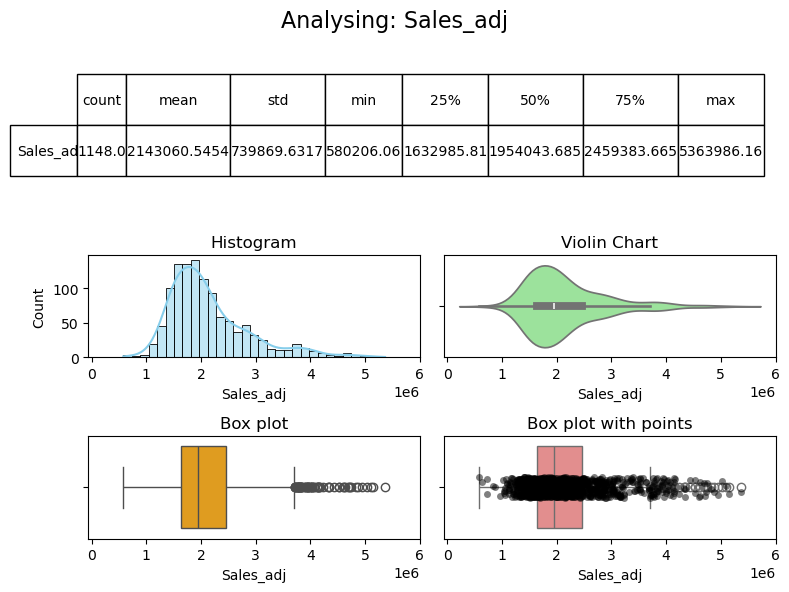

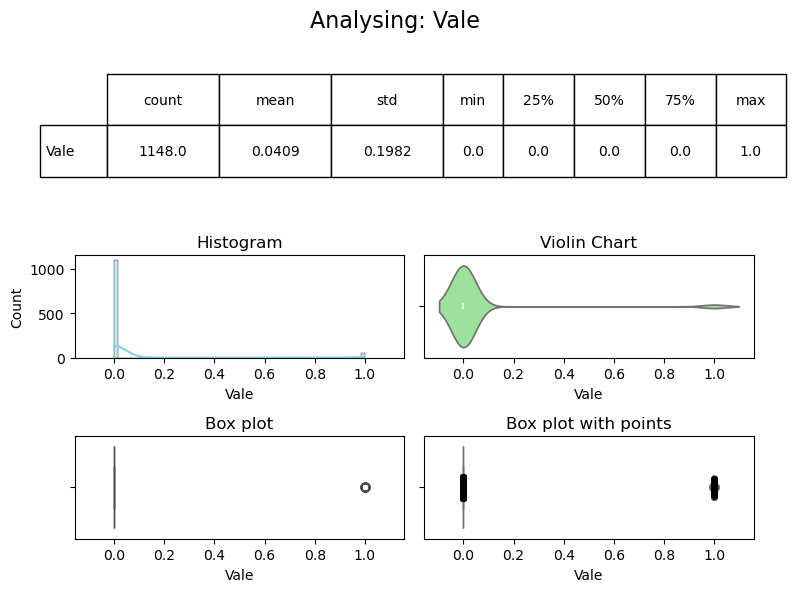

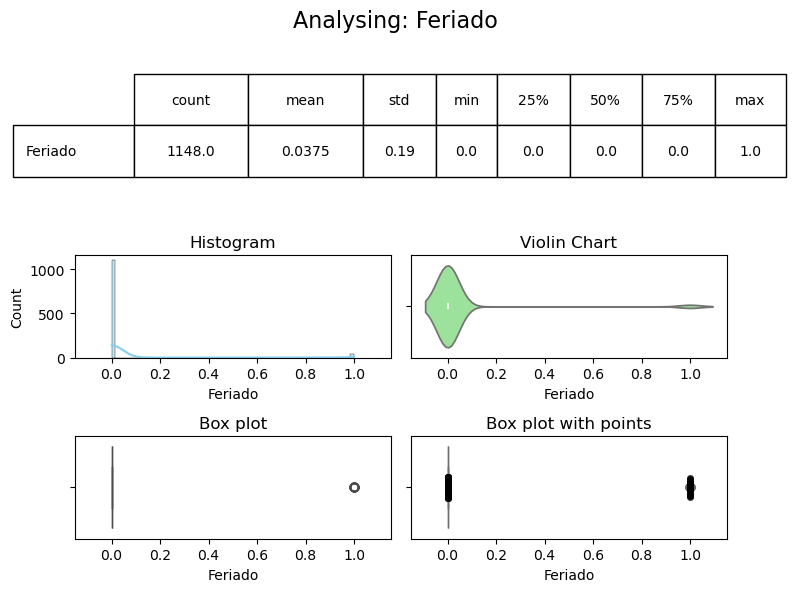

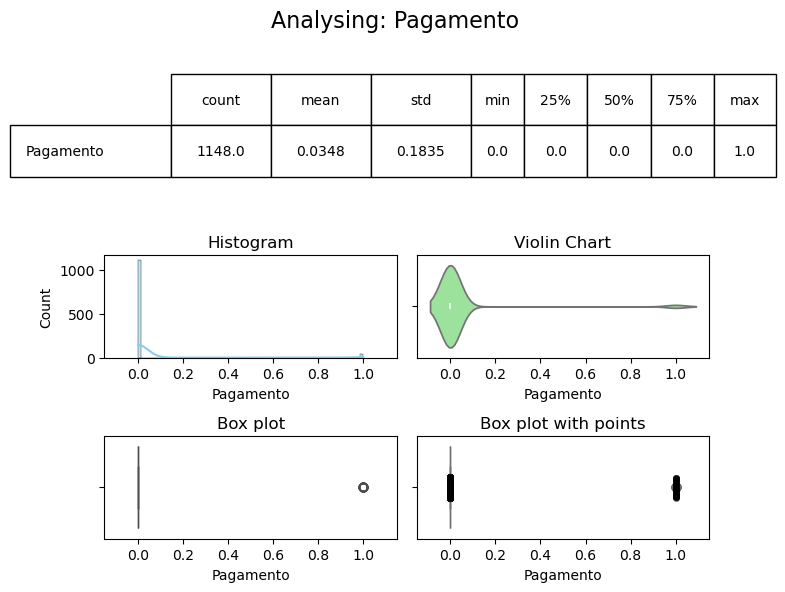

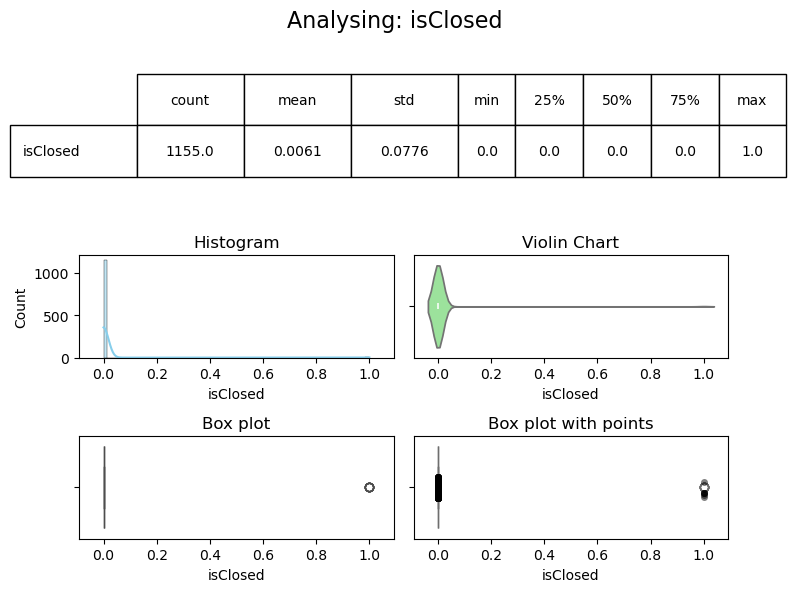

In [769]:
# univariate analysis
univariate_numeric_variable(df_complete, "Sales_adj")

univariate_numeric_variable(df_complete, "Vale")

univariate_numeric_variable(df_complete, "Feriado")

univariate_numeric_variable(df_complete, "Pagamento")

univariate_numeric_variable(df_complete, "isClosed")

## Data Visualization: Understanding the Business Context

        Date   Sales_adj  Feriado  Pagamento  Vale
0 2018-01-01        0.00      NaN        NaN   NaN
1 2018-01-02  1812134.19      0.0        0.0   0.0
2 2018-01-03  1622115.60      0.0        0.0   0.0
3 2018-01-04  1486888.42      0.0        0.0   0.0
4 2018-01-05  2015469.36      0.0        1.0   0.0


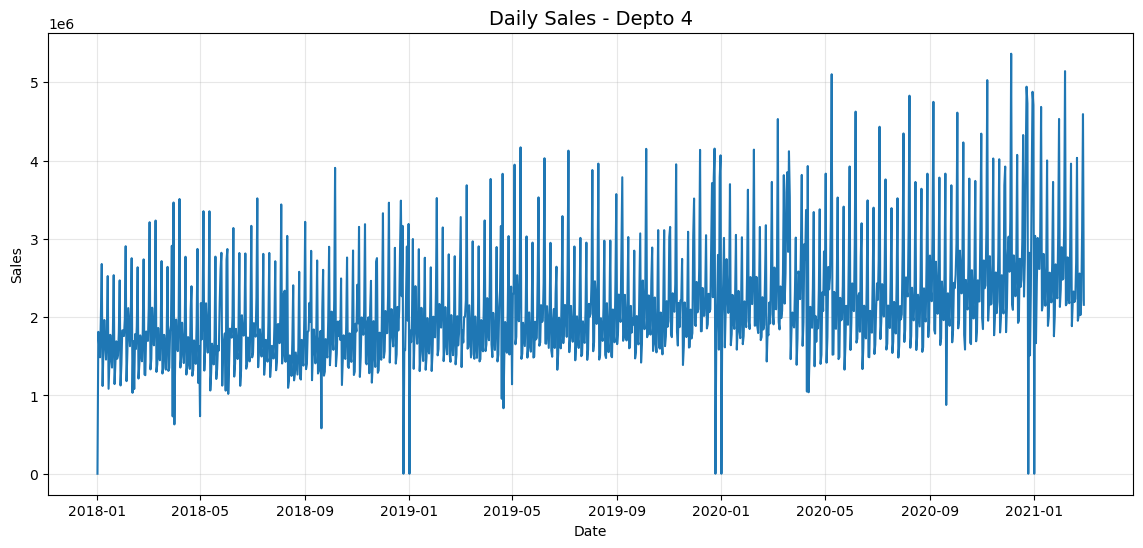

In [772]:
# aggregate by date
df_daily = df_complete.groupby("Date").agg({
    'Sales_adj': 'sum',           # Sum sales for the day
    'Feriado': 'max',         # Max flag (1 if any record is holiday, else 0)
    'Pagamento': 'max',
    'Vale': 'max'
}).reset_index()

# Display result
print(df_daily.head())

# Time series plot of the target variable
plt.figure(figsize=(14, 6))
plt.plot(df_daily['Date'], df_daily['Sales_adj'])
plt.title(f'Daily Sales - {choose_dept}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

Date range: 2018-01-01 00:00:00 to 2021-02-28 00:00:00
Total days in range: 1155
Actual rows: 1155
Missing days: 0
        Date   Sales_adj  Feriado  Pagamento  Vale
0 2018-01-01        0.00      0.0        0.0   0.0
1 2018-01-02  1812134.19      0.0        0.0   0.0
2 2018-01-03  1622115.60      0.0        0.0   0.0
3 2018-01-04  1486888.42      0.0        0.0   0.0
4 2018-01-05  2015469.36      0.0        1.0   0.0
Total rows after filling: 1155


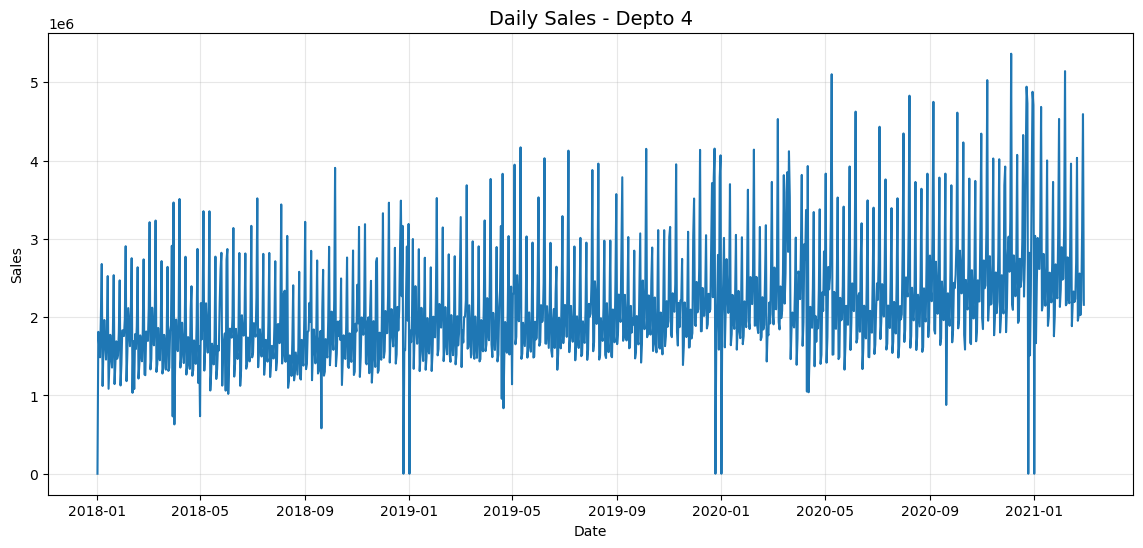

In [773]:
# Check if we have all dates in your range
print(f"Date range: {df_daily['Date'].min()} to {df_daily['Date'].max()}")
print(f"Total days in range: {(df_daily['Date'].max() - df_daily['Date'].min()).days + 1}")
print(f"Actual rows: {len(df_daily)}")
print(f"Missing days: {((df_daily['Date'].max() - df_daily['Date'].min()).days + 1) - len(df_daily)}")

# create complete date range
date_range = pd.date_range(
    start=df_daily['Date'].min(), 
    end=df_daily['Date'].max(),
    freq='D'  # Daily frequency
)

# reindex to include all dates
df_complete = df_daily.set_index('Date').reindex(date_range).reset_index()
df_complete.rename(columns={'index': 'Date'}, inplace=True)

# fill missing values
df_complete['Sales_adj'] = df_complete['Sales_adj'].fillna(0.000001)  # Or use other methods
df_complete['Feriado'] = df_complete['Feriado'].fillna(0)     # Default to not holiday
df_complete['Pagamento'] = df_complete['Pagamento'].fillna(0)
df_complete['Vale'] = df_complete['Vale'].fillna(0)

print(df_complete.head())
print(f"Total rows after filling: {len(df_complete)}")

# Time series plot of the target variable
plt.figure(figsize=(14, 6))
plt.plot(df_complete['Date'], df_complete['Sales_adj'])
plt.title(f'Daily Sales - {choose_dept}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()


# Time Series Analysis - Step A: Visual Analysis



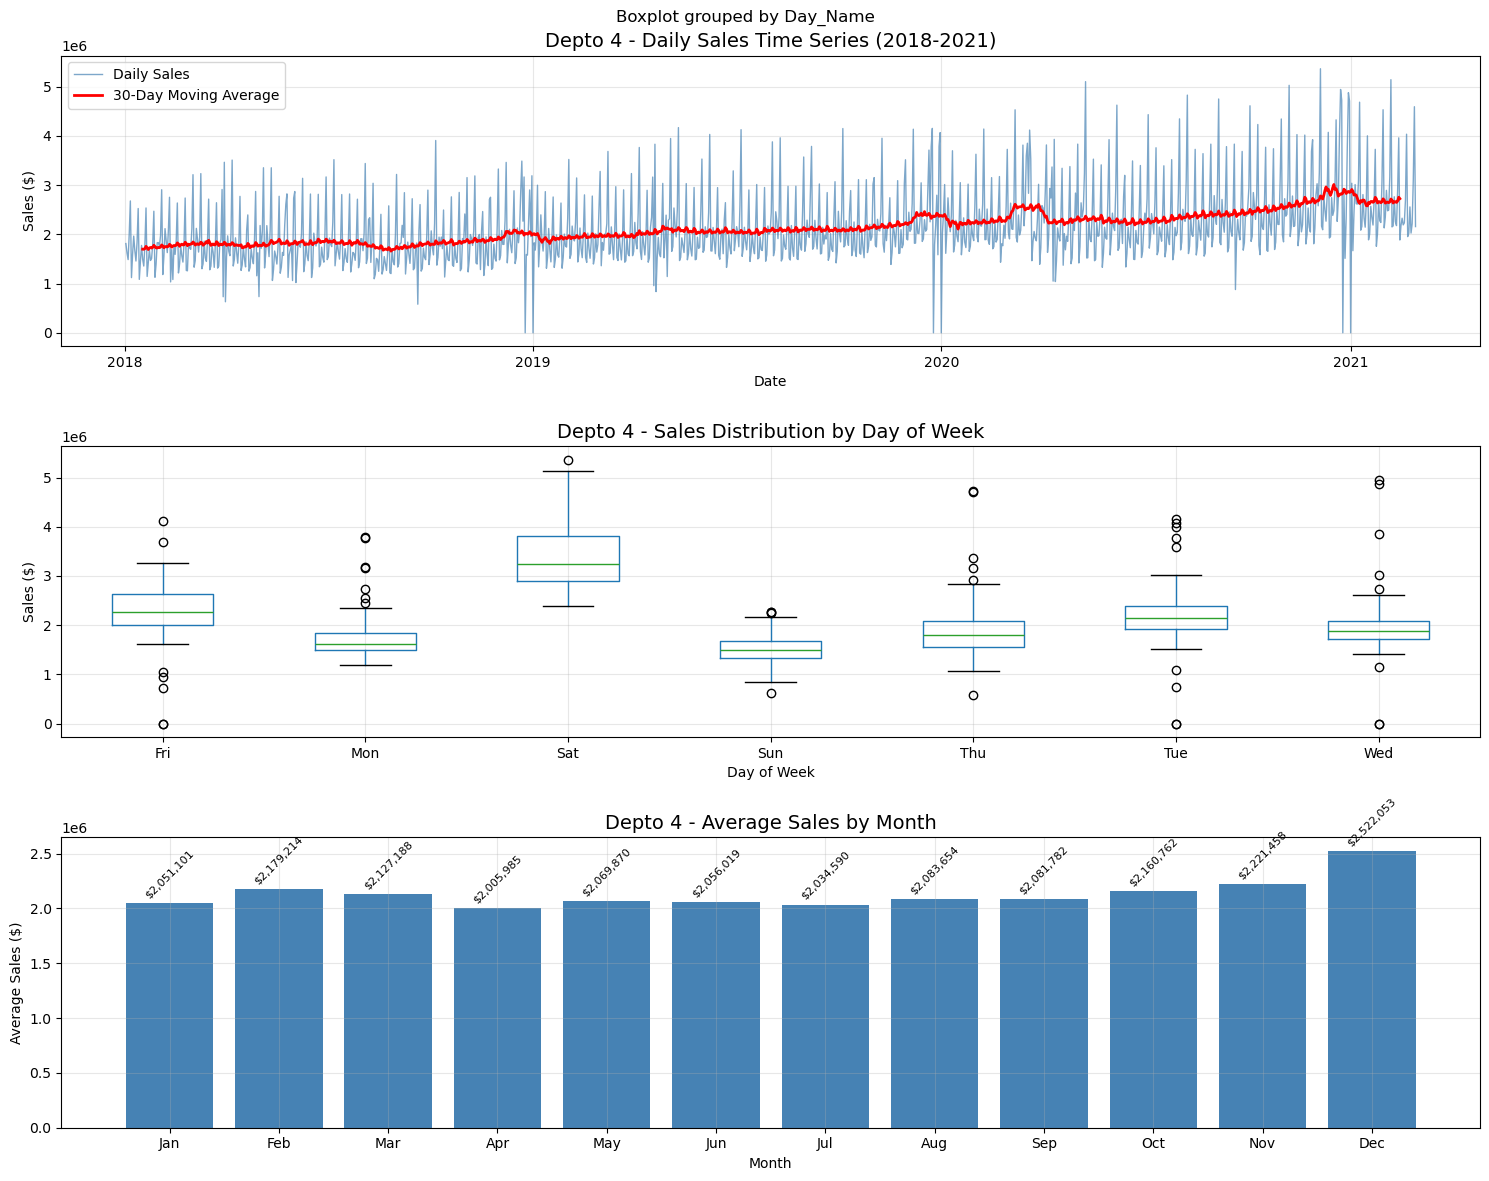

In [18]:
# Prepare the time series data
# Use the complete daily data we created earlier
ts = df_complete.set_index('Date')['Sales']

# Create time series plot with trend line
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Full time series with trend
axes[0].plot(ts.index, ts.values, linewidth=1.0, alpha=0.7, color='steelblue', label='Daily Sales')
# Add trend line using moving average (30-day)
ts_ma = ts.rolling(window=30, center=True).mean()
axes[0].plot(ts_ma.index, ts_ma.values, linewidth=2, color='red', label='30-Day Moving Average')
axes[0].set_title(f'{choose_dept} - Daily Sales Time Series (2018-2021)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Format x-axis
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Plot 2: Box plot by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# Add day of week to dataframe
df_complete['Day_of_Week'] = df_complete['Date'].dt.dayofweek + 1  # Monday=1
df_complete['Day_Name'] = df_complete['Day_of_Week'].map(lambda x: day_names[x-1])

# Box plot
df_complete.boxplot(column='Sales', by='Day_Name', ax=axes[1])
axes[1].set_title(f'{choose_dept} - Sales Distribution by Day of Week', fontsize=14)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Sales ($)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Monthly averages
monthly_avg = df_complete.groupby(df_complete['Date'].dt.month)['Sales'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[2].bar(month_names, monthly_avg.values, color='steelblue')
axes[2].set_title(f'{choose_dept} - Average Sales by Month', fontsize=14)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Sales ($)')
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(monthly_avg.values):
    axes[2].text(i, v + max(monthly_avg.values)*0.01, f'${v:,.0f}', 
                 ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

## Seasonal Subseries Plot

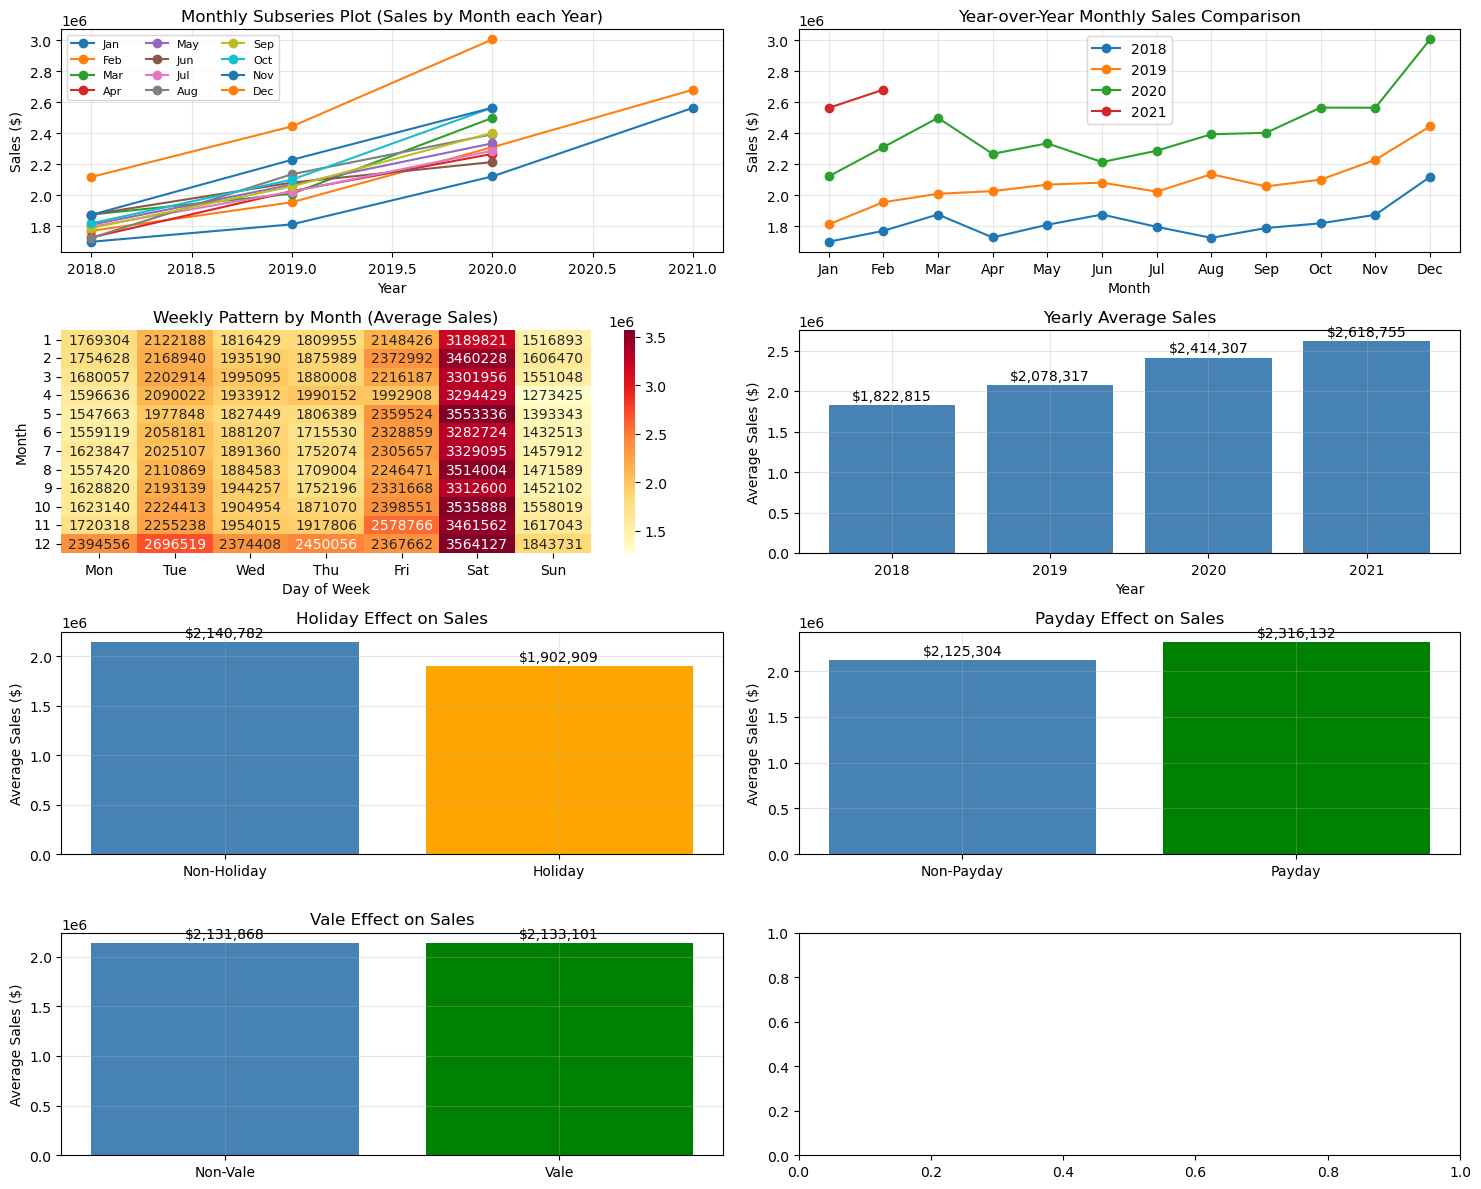

In [24]:
# Seasonal subseries plot - Monthly patterns
fig, axes = plt.subplots(4, 2, figsize=(15, 12))

# Prepare data for subseries plot
df_complete['Year'] = df_complete['Date'].dt.year
df_complete['Month'] = df_complete['Date'].dt.month

# Create subseries plot - using pivot_table to handle duplicates
monthly_data = df_complete.pivot_table(index='Year', columns='Month', values='Sales', aggfunc='mean')
monthly_data.columns = month_names

# Plot 1: Monthly subseries plot
for month in month_names:
    axes[0, 0].plot(monthly_data.index, monthly_data[month].values, 
                    marker='o', label=month, linewidth=1.5)
axes[0, 0].set_title('Monthly Subseries Plot (Sales by Month each Year)', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].legend(loc='best', ncol=3, fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Year-over-year comparison
for year in monthly_data.index:
    axes[0, 1].plot(month_names, monthly_data.loc[year].values, 
                    marker='o', label=str(year), linewidth=1.5)
axes[0, 1].set_title('Year-over-Year Monthly Sales Comparison', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Sales ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Weekly seasonality heatmap
# Create day of week patterns by month
weekly_pattern = df_complete.pivot_table(index='Month', columns='Day_Name', values='Sales', aggfunc='mean')
# Ensure all days are present
all_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for day in all_days:
    if day not in weekly_pattern.columns:
        weekly_pattern[day] = 0
weekly_pattern = weekly_pattern[all_days]  # Reorder columns

sns.heatmap(weekly_pattern, ax=axes[1, 0], cmap='YlOrRd', annot=True, fmt='.0f')
axes[1, 0].set_title('Weekly Pattern by Month (Average Sales)', fontsize=12)
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Month')

# Plot 4: Yearly comparison
yearly_avg = df_complete.groupby(df_complete['Date'].dt.year)['Sales'].mean()
axes[1, 1].bar(yearly_avg.index.astype(str), yearly_avg.values, color='steelblue')
axes[1, 1].set_title('Yearly Average Sales', fontsize=12)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Sales ($)')
axes[1, 1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(yearly_avg.values):
    axes[1, 1].text(i, v + max(yearly_avg.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 5: Holiday effect
holiday_effect = df_complete.groupby('Feriado')['Sales'].mean()
axes[2, 0].bar(['Non-Holiday', 'Holiday'], holiday_effect.values, 
               color=['steelblue', 'orange'])
axes[2, 0].set_title('Holiday Effect on Sales', fontsize=12)
axes[2, 0].set_ylabel('Average Sales ($)')
axes[2, 0].grid(True, alpha=0.3)
for i, v in enumerate(holiday_effect.values):
    axes[2, 0].text(i, v + max(holiday_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 6: Payday effect
payday_effect = df_complete.groupby('Pagamento')['Sales'].mean()
axes[2, 1].bar(['Non-Payday', 'Payday'], payday_effect.values, 
               color=['steelblue', 'green'])
axes[2, 1].set_title('Payday Effect on Sales', fontsize=12)
axes[2, 1].set_ylabel('Average Sales ($)')
axes[2, 1].grid(True, alpha=0.3)
for i, v in enumerate(payday_effect.values):
    axes[2, 1].text(i, v + max(payday_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 7: Vale effect
vale_effect = df_complete.groupby('Vale')['Sales'].mean()
axes[3, 0].bar(['Non-Vale', 'Vale'], vale_effect.values, 
               color=['steelblue', 'green'])
axes[3, 0].set_title('Vale Effect on Sales', fontsize=12)
axes[3, 0].set_ylabel('Average Sales ($)')
axes[3, 0].grid(True, alpha=0.3)
for i, v in enumerate(vale_effect.values):
    axes[3, 0].text(i, v + max(vale_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')



plt.tight_layout()
plt.show()

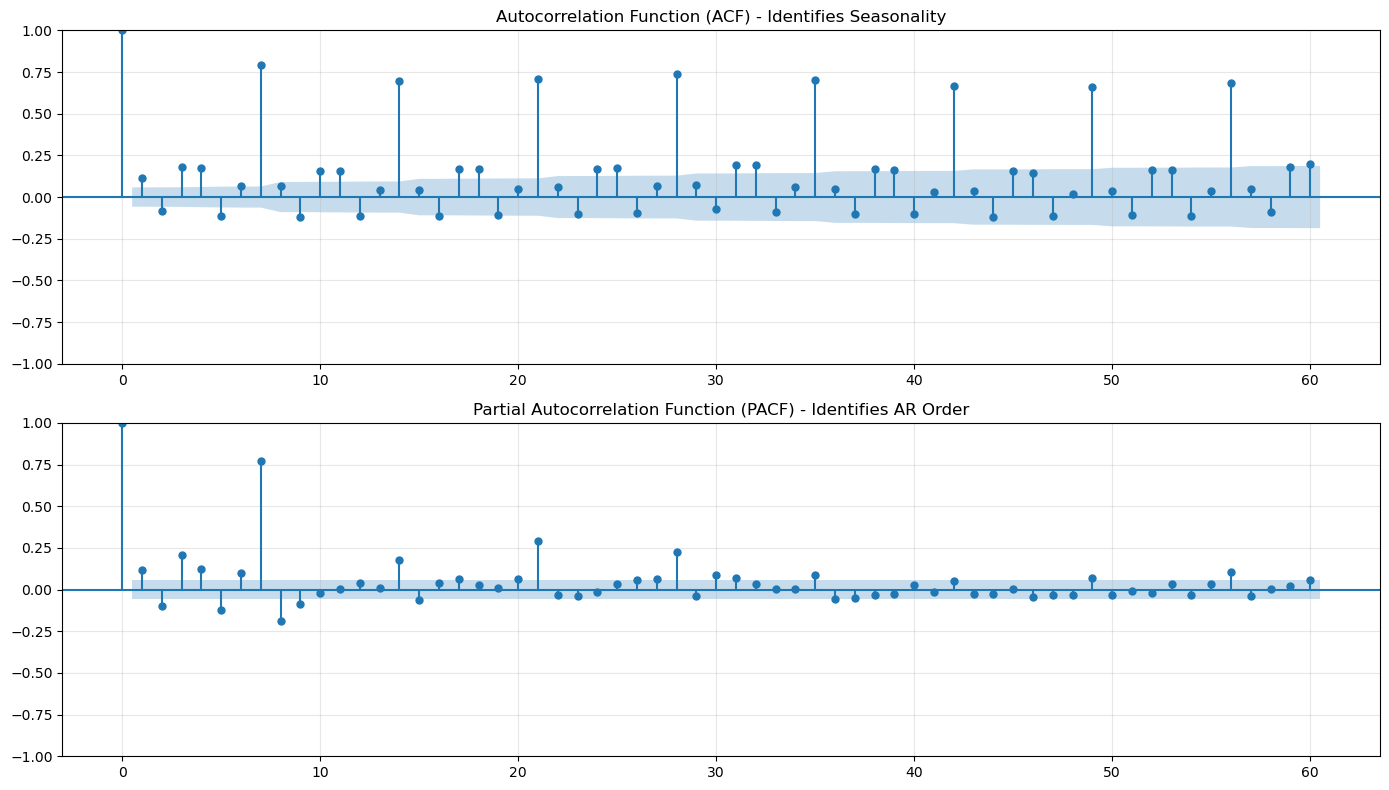

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts.dropna(), lags=60, ax=ax1, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF) - Identifies Seasonality', fontsize=12)
ax1.grid(True, alpha=0.3)

plot_pacf(ts.dropna(), lags=60, ax=ax2, alpha=0.05)
ax2.set_title('Partial Autocorrelation Function (PACF) - Identifies AR Order', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Calculate key statistics
total_sales = ts.sum()
avg_daily = ts.mean()
median_daily = ts.median()

print(f"\n1. OVERALL SALES PERFORMANCE:")
print(f"   - Total sales over period: ${total_sales:,.2f}")
print(f"   - Average daily sales: ${avg_daily:,.2f}")
print(f"   - Median daily sales: ${median_daily:,.2f}")

# Trend analysis
print(f"\n2. TREND ANALYSIS:")
yearly_avg = df_complete.groupby(df_complete['Date'].dt.year)['Sales'].mean()
if len(yearly_avg) >= 2:
    first_year = yearly_avg.index[0]
    last_year = yearly_avg.index[-1]
    change_pct = ((yearly_avg[last_year] - yearly_avg[first_year]) / yearly_avg[first_year]) * 100
    if change_pct > 0:
        print(f"   → {change_pct:.1f}% INCREASING trend from {first_year} to {last_year}")
    else:
        print(f"   → {abs(change_pct):.1f}% DECREASING trend from {first_year} to {last_year}")

# Weekly seasonality
print(f"\n3. WEEKLY SEASONALITY:")
weekly_pattern = df_complete.groupby('Day_Name')['Sales'].mean()
best_day = weekly_pattern.idxmax()
best_value = weekly_pattern[best_day]
worst_day = weekly_pattern.idxmin()
worst_value = weekly_pattern[worst_day]
print(f"   → Busiest day: {best_day} (${best_value:,.2f} average)")
print(f"   → Slowest day: {worst_day} (${worst_value:,.2f} average)")
print(f"   → Peak-to-valley ratio: {best_value/worst_value:.2f}x")

# Monthly patterns
print(f"\n4. MONTHLY/ANNUAL PATTERNS:")
monthly_pattern = df_complete.groupby(df_complete['Date'].dt.month)['Sales'].mean()
best_month = monthly_pattern.idxmax()
worst_month = monthly_pattern.idxmin()
print(f"   → Peak month: {month_names[best_month-1]} (${monthly_pattern[best_month]:,.2f} avg)")
print(f"   → Lowest month: {month_names[worst_month-1]} (${monthly_pattern[worst_month]:,.2f} avg)")

# Exogenous effects
print(f"\n5. EXOGENOUS EFFECTS:")
if 1 in holiday_effect.index and 0 in holiday_effect.index:
    holiday_pct = ((holiday_effect[1] - holiday_effect[0]) / holiday_effect[0]) * 100
    print(f"   → Holiday impact: {holiday_pct:+.1f}% change")

if 1 in payday_effect.index and 0 in payday_effect.index:
    payday_pct = ((payday_effect[1] - payday_effect[0]) / payday_effect[0]) * 100
    print(f"   → Payday impact: {payday_pct:+.1f}% change")

if 1 in vale_effect.index and 0 in vale_effect.index:
    vale_pct = ((vale_effect[1] - vale_effect[0]) / vale_effect[0]) * 100
    print(f"   → Vale impact: {vale_pct:+.1f}% change")

# Seasonality detection
print(f"\n6. SEASONALITY DETECTION (from ACF):")
print(f"   → Significant autocorrelation at lag 7 suggests WEEKLY seasonality")




1. OVERALL SALES PERFORMANCE:
   - Total sales over period: $2,460,233,500.46
   - Average daily sales: $2,131,918.11
   - Median daily sales: $1,951,246.26

2. TREND ANALYSIS:
   → 43.7% INCREASING trend from 2018 to 2021

3. WEEKLY SEASONALITY:
   → Busiest day: Sat ($3,396,802.12 average)
   → Slowest day: Sun ($1,517,812.06 average)
   → Peak-to-valley ratio: 2.24x

4. MONTHLY/ANNUAL PATTERNS:
   → Peak month: Dec ($2,522,052.79 avg)
   → Lowest month: Apr ($2,005,984.58 avg)

5. EXOGENOUS EFFECTS:
   → Holiday impact: -11.1% change
   → Payday impact: +9.0% change
   → Vale impact: +0.1% change

6. SEASONALITY DETECTION (from ACF):
   → Significant autocorrelation at lag 7 suggests WEEKLY seasonality


## Business Insights from Visual Analysis

The statistics above, together with the time series, box-plot, subseries, and ACF/PACF charts, point to a consistent set of patterns:

- **Trend**: Daily sales grew **43.7%** from 2018 to 2021 — a strong, sustained upward trend rather than noise. Step E should isolate and quantify this trend explicitly, since it changes the *level* the model needs to forecast, not just its shape.

- **Weekly seasonality**: **Saturday** is the busiest day (avg. **\$3,396,802**) and **Sunday** the slowest (avg. **\$1,517,812**) — a peak-to-valley ratio of **2.24x**. The ACF plot confirms a clear spike around **lag 7**, consistent with a 7-day cycle. This is the strongest seasonal signal in the series and should anchor `s=7` for SARIMA and the seasonal period for Exponential Smoothing.

- **Monthly / annual pattern**: **December** is the peak month (avg. **\$2,522,053**), plausibly holiday shopping; **April** is the lowest (avg. **\$2,005,985**), a plausible post-holiday slowdown. With only ~3 full years of data, Step D/E (differencing, decomposition) should confirm whether this repeats every year or is driven by a single year, rather than assuming it.

- **Exogenous effects**:
    - **Holidays**: sales drop **-11.1%** on flagged holidays — consistent with stores closing or operating reduced hours.
    - **Paydays**: sales rise **+9.0%** — consumers spending shortly after being paid.
    - **Vale (voucher) days**: **+0.1%**, essentially no effect at the aggregate department level — worth testing as a regressor anyway, but not expected to add much explanatory power.
    - These three flags for future dates are reconstructed using the rules in *Business Rules — Summary* above; their imperfect match rate (68–76%) is a known source of uncertainty carried into Step F2.

**Implication for modeling (Step F)**: trend + weekly seasonality + at least two material exogenous effects rules out a plain white-noise or purely level-based model. A seasonal model — SARIMA with `s=7`, or Holt-Winters with trend and a weekly seasonal component — plus `Feriado`/`Pagamento` as exogenous regressors is the natural starting point. Whether an additional annual seasonal term is needed depends on the stationarity/decomposition results in Steps D–E.


---
### Wrap-up: Step A → Step B

Step A established: (1) a strong increasing trend, (2) weekly seasonality with `s=7`, (3) a plausible but unconfirmed annual pattern, and (4) two exogenous effects worth carrying forward (`Feriado`, `Pagamento`). These four findings are the inputs to every step that follows — they are referenced again in Step E (component identification) and Step F (model selection).

Next: split the data into training and holdout sets before doing any further statistical testing, so that all of Steps C–H are learned only on the training data.

---


# Step B — Train / Holdout Split

**Objective**: split `ts` (daily Sales) into a training set (through Dec/2020) and a holdout set (Jan–Feb/2021), matching the *Data Description* at the top of this notebook. The holdout is never touched until Step I — all identification, estimation and diagnostics (Steps C–H) run on the training data only.

In [ ]:
# Step B: Train / Holdout split
train_end = '2020-12-31'
holdout_start = '2021-01-01'
holdout_end = '2021-02-28'

ts_train = ts.loc[:train_end]
ts_holdout = ts.loc[holdout_start:holdout_end]

print(f"Train:   {ts_train.index.min().date()} to {ts_train.index.max().date()}  ({len(ts_train)} obs)")
print(f"Holdout: {ts_holdout.index.min().date()} to {ts_holdout.index.max().date()}  ({len(ts_holdout)} obs)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, ts_train.values, label='Train', linewidth=0.8)
ax.plot(ts_holdout.index, ts_holdout.values, label='Holdout', color='orange', linewidth=1.2)
ax.axvline(pd.Timestamp(train_end), color='red', linestyle='--', label='Split point')
ax.legend(); ax.set_title('Train / Holdout Split'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Business Justification for the Split

- **Training data** represents the "known" historical performance used to identify and estimate the model.
- **Holdout data** (Jan–Feb/2021) simulates "future" data — it validates model accuracy before it is trusted to forecast March/2021.
- This mirrors how the model will actually be used in production: fit on history, judged on data it has never seen, then deployed to forecast forward.


# Step C — White Noise Verification

**Objective**: confirm the training series is *not* white noise before investing in a model — if it were, no model could beat a naive mean/last-value forecast, and the whole exercise (Steps D–J) would be moot.

**Method**: Ljung-Box test on `ts_train`, plus a visual ACF check.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(ts_train, lags=[7, 14, 21, 30], return_df=True)
print(lb_test)

**Interpretation guide**:
- H0: the series is white noise (no autocorrelation at the tested lags).
- Decision rule: if the p-value < 0.05 at any lag, reject H0 → the series has exploitable structure.
- [Fill in] p-values obtained and conclusion, referencing back to the ACF/PACF plot from Step A.

## ACF Plot for White Noise Check

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(ts_train.dropna(), lags=40, ax=ax, alpha=0.05)
ax.set_title('ACF of Training Series — White Noise Check')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# A white-noise series would show (almost) all bars inside the confidence band.
# Compare this to what you already saw at lag 7 in Step A.

# Step D — Stationarity Check

**Objective**: determine whether `ts_train` is stationary, and if not, how much differencing (`d`, and seasonal `D`) is needed before ARIMA/SARIMA can be applied. Exponential smoothing (Step F1) does not require stationarity, but ARIMA (Step F2) does.

**Method**: Augmented Dickey-Fuller (ADF) test, applied to the level series and then to differenced versions.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label=''):
    result = adfuller(series.dropna())
    print(f"ADF Test — {label}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"  Critical Value ({k}): {v:.4f}")
    conclusion = 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    print(f"  Conclusion: {conclusion} (alpha = 0.05)\n")
    return result

run_adf(ts_train, 'Sales (level)')

## Differencing if Needed

In [ ]:
# If the level series is non-stationary, test regular and seasonal differencing.
# Seasonal period s=7 comes from the weekly seasonality confirmed in Step A.

ts_diff1 = ts_train.diff().dropna()
run_adf(ts_diff1, 'after 1st regular difference (d=1)')

ts_seasdiff = ts_train.diff(7).dropna()
run_adf(ts_seasdiff, 'after seasonal difference (D=1, s=7)')

# If still non-stationary, try both combined:
ts_diff1_seasdiff = ts_train.diff().diff(7).dropna()
run_adf(ts_diff1_seasdiff, 'after regular + seasonal difference (d=1, D=1, s=7)')

## Determine d and D Parameters

- [Fill in] **d** = ___ (smallest number of regular differences that achieves stationarity)
- [Fill in] **D** = ___ (smallest number of seasonal differences, s=7, that achieves stationarity)
- **Watch for over-differencing**: a strongly negative spike at lag 1 (or lag 7) in the ACF of the differenced series is a sign of having differenced one time too many — check the ACF/PACF of whichever differenced series you settle on before moving to Step E/F2.

# Step E — Component Identification: Trend, Seasonality, Cycle

**Objective**: formally decompose `ts_train` into trend, seasonal, and residual components, to confirm (rather than assume) what Step A suggested visually.

**Method**: classical decomposition with `seasonal_decompose` (period=7, from the confirmed weekly seasonality).

In [ ]:
decomposition = seasonal_decompose(ts_train, model='additive', period=7)
# Try model='multiplicative' as well if the seasonal amplitude appears to grow with the trend (see Step A plots)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomposition.observed); axes[0].set_title('Observed'); axes[0].grid(alpha=0.3)
axes[1].plot(decomposition.trend); axes[1].set_title('Trend'); axes[1].grid(alpha=0.3)
axes[2].plot(decomposition.seasonal); axes[2].set_title('Seasonal (weekly, s=7)'); axes[2].grid(alpha=0.3)
axes[3].plot(decomposition.resid); axes[3].set_title('Residual'); axes[3].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Seasonal Component Analysis

In [ ]:
# Check for an additional annual pattern beyond the weekly one already confirmed.
# Caution: with ~3 years of training data, an annual estimate is based on only 3 cycles -- treat it as indicative, not conclusive.

monthly_avg_by_year = ts_train.groupby([ts_train.index.year, ts_train.index.month]).mean().unstack(level=0)
monthly_avg_by_year.plot(figsize=(12, 5), marker='o')
plt.title('Monthly Average by Year — is Dec-peak/Apr-trough consistent every year?')
plt.xlabel('Month'); plt.ylabel('Average Sales ($)'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Business Component Identification Summary

Components identified (weekly seasonality and exogenous effects are already confirmed from Step A; trend shape, monthly/annual pattern and cycle should be confirmed against the decomposition above):

- **Trend**: Increasing (~43.7% growth 2018→2021, confirmed in Step A). [Fill in: does the decomposition trend line look closer to linear or exponential/multiplicative growth?]

- **Seasonality**:
    - **Weekly**: Confirmed — 7-day cycle, Saturday peak / Sunday trough (2.24x ratio), also the dominant ACF spike at lag 7.
    - **Monthly**: [Fill in — is Dec-peak / Apr-trough repeated across all 3 years in the plot above, or driven by one year?]
    - **Annual**: [Fill in — note the data limitation: only ~3 full cycles available.]

- **Cycle**: [Fill in — any multi-year pattern beyond trend + the seasonal components above? With 3 years of data this is hard to separate from the trend itself.]

- **Exogenous Effects** (carried over from Step A / Business Rules Summary):
    - Holidays: **-11.1%** average impact
    - Paydays: **+9.0%** average impact
    - Voucher days: **+0.1%** average impact — likely not a useful regressor on its own


# Step F — Model Fitting

## F1 — Exponential Smoothing

**Model selection based on components identified in Step E**: the series has both a **trend** and **weekly seasonality**, which rules out Simple Exponential Smoothing (no trend/season) and Holt's method (trend only, no season). This points to **Holt-Winters / Triple Exponential Smoothing**, with `seasonal_periods=7`.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Compare additive vs multiplicative trend/seasonal combinations
hw_candidates = {}
for trend_type in ['add', 'mul']:
    for seasonal_type in ['add', 'mul']:
        try:
            m = ExponentialSmoothing(
                ts_train, trend=trend_type, seasonal=seasonal_type,
                seasonal_periods=7, damped_trend=False
            ).fit()
            hw_candidates[f'trend={trend_type}, seasonal={seasonal_type}'] = m
            print(f"trend={trend_type}, seasonal={seasonal_type}  ->  AIC={m.aic:.1f}")
        except Exception as e:
            print(f"trend={trend_type}, seasonal={seasonal_type}  ->  failed ({e})")

## Model Evaluation

- Compare the AIC of each additive/multiplicative combination above (lower is better).
- Also try `damped_trend=True` for the winning combination — a damped trend is often more realistic over a 30-day forecast horizon than assuming growth continues linearly forever.
- [Fill in] Chosen configuration and why (AIC value + business reasoning, e.g. whether sales growth is expected to keep accelerating).

## F2 — ARIMA / SARIMA Family

### Parameter Identification (p, d, q) — Non-Seasonal

Use the ACF/PACF of the **differenced** series chosen in Step D (whichever combination of `ts_diff1` / `ts_seasdiff` / `ts_diff1_seasdiff` achieved stationarity).

In [ ]:
# Replace `ts_diff1` below with whichever differenced series was chosen as stationary in Step D
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(ts_diff1, lags=40, ax=ax1, alpha=0.05)
ax1.set_title('ACF of differenced series — informs q'); ax1.grid(alpha=0.3)
plot_pacf(ts_diff1, lags=40, ax=ax2, alpha=0.05)
ax2.set_title('PACF of differenced series — informs p'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

- **q** (MA order): last lag with a significant spike in the ACF before it cuts off/decays.
- **p** (AR order): last lag with a significant spike in the PACF.
- [Fill in] **p** = ___, **d** = ___ (from Step D), **q** = ___

### Parameter Identification (P, D, Q, s) — Seasonal

Same logic, but look at the spikes around the seasonal lags (7, 14, 21, ...) on the seasonally-differenced series.

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(ts_seasdiff, lags=42, ax=ax1, alpha=0.05)
ax1.set_title('ACF of seasonally-differenced series — informs Q'); ax1.grid(alpha=0.3)
plot_pacf(ts_seasdiff, lags=42, ax=ax2, alpha=0.05)
ax2.set_title('PACF of seasonally-differenced series — informs P'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

- [Fill in] **P** = ___, **D** = ___ (from Step D), **Q** = ___, **s** = 7 (weekly, confirmed since Step A)

## Model Estimation — SARIMA

In [ ]:
import statsmodels.api as sm

order = (1, 1, 1)               # replace with (p, d, q) identified above
seasonal_order = (1, 1, 1, 7)   # replace with (P, D, Q, 7) identified above

model_sarima = sm.tsa.statespace.SARIMAX(
    ts_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(model_sarima.summary())

## SARIMA with Exogenous Variables

Add `Feriado` and `Pagamento` as exogenous regressors (from the Business Rules Summary — `Vale` showed ~0% aggregate effect in Step A, so it's a candidate to test but not a default include).

In [ ]:
exog_cols = ['Feriado', 'Pagamento']  # add 'Vale' here too if you want to test it explicitly

exog_train = df_complete.set_index('Date').loc[ts_train.index, exog_cols]

model_sarimax = sm.tsa.statespace.SARIMAX(
    ts_train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(model_sarimax.summary())

## Evaluation of the Estimated Coefficients

- Check the p-value of every coefficient (AR/MA terms and each exogenous regressor) — anything with p > 0.05 is a candidate to drop or reconsider.
- Compare AIC/BIC of `model_sarima` vs. `model_sarimax` — the exogenous variables should only be kept if they meaningfully improve fit, not merely because they're available.
- [Fill in] which coefficients are significant, and the AIC/BIC comparison between SARIMA and SARIMAX.

# Step G — Choosing the Best Model

**Objective**: compare every candidate fitted so far (Holt-Winters variants, SARIMA, SARIMAX) on a common footing, using out-of-sample accuracy on the holdout — not in-sample fit, which always favors the more complex model.

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Generate each candidate's holdout forecast, then evaluate. Example pattern for one model:
# hw_forecast = hw_candidates['trend=add, seasonal=add'].forecast(len(ts_holdout))
# sarima_forecast = model_sarima.get_forecast(len(ts_holdout)).predicted_mean
# exog_holdout = df_complete.set_index('Date').loc[ts_holdout.index, exog_cols]
# sarimax_forecast = model_sarimax.get_forecast(len(ts_holdout), exog=exog_holdout).predicted_mean

results = []
# results.append(evaluate_forecast(ts_holdout, hw_forecast, 'Holt-Winters'))
# results.append(evaluate_forecast(ts_holdout, sarima_forecast, 'SARIMA'))
# results.append(evaluate_forecast(ts_holdout, sarimax_forecast, 'SARIMAX'))

comparison_df = pd.DataFrame(results).sort_values('RMSE')
comparison_df

## Business Decision Matrix

Model selection criteria:
- **Accuracy**: lower prediction error (MAE/RMSE/MAPE) on the holdout.
- **Stability**: consistent performance across different sub-periods, not just the overall average.
- **Interpretability**: how easily the model's logic can be explained to non-technical stakeholders.
- **Exogenous integration**: ability to incorporate known future business events (paydays, holidays).
- **Complexity**: balance between accuracy gained and the added complexity/maintenance cost.

**Selected Model**: [Fill in model name]

**Justification**: [Fill in — reference the comparison table above and weigh the criteria]

# Step H — Diagnostics: Residual Analysis

**Objective**: verify the selected model's residuals behave like white noise. If they don't, the model is leaving predictable structure on the table and should be revisited (back to Step F).

In [ ]:
best_model = model_sarimax  # replace with whichever model was selected in Step G

residuals = best_model.resid

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(residuals)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuals over Time'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Residual Distribution Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, kde=True, ax=axes[0]); axes[0].set_title('Residual Distribution')
sm.qqplot(residuals, line='s', ax=axes[1]); axes[1].set_title('Q-Q Plot (Normality Check)')
plt.tight_layout(); plt.show()

## Residual Autocorrelation Check

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(residuals.dropna(), lags=40, ax=ax, alpha=0.05)
ax.set_title('Residual ACF — should show (almost) no significant autocorrelation')
plt.tight_layout(); plt.show()

lb_resid = acorr_ljungbox(residuals.dropna(), lags=[7, 14, 21], return_df=True)
print(lb_resid)

## Business Interpretation of Diagnostics

- **Residuals**: [Fill in — approximately normal? any remaining spikes in the ACF, particularly at lag 7?]
- **Model assumptions**: [Fill in — are they reasonably met, or is there a specific violation (e.g., residual autocorrelation at a particular lag)?]
- **Business confidence**: [Fill in — how much trust should stakeholders place in the point forecasts and the 95% intervals?]
- **Limitations**: [Fill in — e.g., known imperfect reconstruction of `Pagamento`/`Vale` for future dates, only ~3 years of history for annual seasonality, etc.]

# Step I — Holdout Error Metrics

**Objective**: quantify how well the selected model would have performed had it been used to forecast Jan–Feb/2021 without ever seeing that data.

In [ ]:
exog_holdout = df_complete.set_index('Date').loc[ts_holdout.index, exog_cols]  # only needed for SARIMAX

forecast_result = best_model.get_forecast(steps=len(ts_holdout), exog=exog_holdout)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

metrics = evaluate_forecast(ts_holdout, forecast_mean, 'Selected Model — Holdout')
print(metrics)

## Visualization of Predictions vs. Actuals

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index[-60:], ts_train.values[-60:], label='Train (last 60 days)')
ax.plot(ts_holdout.index, ts_holdout.values, label='Actual (holdout)', color='black')
ax.plot(forecast_mean.index, forecast_mean.values, label='Forecast', color='red')
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color='red', alpha=0.15, label='95% CI')
ax.legend(); ax.set_title('Holdout: Actual vs. Forecast'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Business Interpretation of Errors

- **Average error (MAE)**: [Fill in value] → on average, the forecast misses by [Value] in daily sales.
- **Percentage error (MAPE)**: [Fill in value]% → on average, the forecast is off by that share of actual sales.
- **Largest errors**: [Fill in — which specific dates had the biggest misses? Cross-check against the holiday/payday calendar and the imperfect `Vale`/`Pagamento` reconstruction rules.]
- **Business acceptability**: [Fill in — is this error rate acceptable for inventory/staffing decisions? Why?]
- **Actionable insights**: [Fill in — what do the errors suggest about what's still missing from the model?]

# Step J — Forecast for the Next Periods

**Objective**: generate the 30-day forecast for March/2021 using the full training history (train + holdout combined, now that the holdout has served its evaluation purpose), and the same exogenous-flag rules derived earlier in the EDA.

## Prepare Future Period Data

In [ ]:
future_start = '2021-03-01'
future_end = '2021-03-31'
future_dates = pd.date_range(future_start, future_end, freq='D')

future_df = pd.DataFrame({'Date': future_dates})

# isClosed rule (Step: Business Rules Summary)
future_df['isClosed'] = (
    ((future_df['Date'].dt.month == 12) & (future_df['Date'].dt.day == 25)) |
    ((future_df['Date'].dt.month == 1) & (future_df['Date'].dt.day == 1))
).astype(int)

# Feriado: map from df_holiday_unique / holiday_names, the same list used earlier in the EDA rule section
future_df = future_df.merge(df_holiday_unique[['Date', 'nome']], on='Date', how='left')
future_df['Feriado'] = future_df['nome'].isin(holiday_names).astype(int)

# Pagamento / Vale: reuse get_payment_date() / get_vale_date() defined earlier in this notebook
payment_date_mar = get_payment_date(2021, 3, df_complete)
vale_dates_mar = get_vale_date(2021, 3, df_complete)

future_df['Pagamento'] = (future_df['Date'] == payment_date_mar).astype(int)
future_df['Vale'] = future_df['Date'].isin(vale_dates_mar).astype(int)

future_df

## Generate Future Forecasts

In [ ]:
exog_future = future_df.set_index('Date')[exog_cols]

future_forecast = best_model.get_forecast(steps=len(future_dates), exog=exog_future)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int(alpha=0.05)

## Final Forecast Table

In [ ]:
forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_mean.values,
    'Lower_95': future_ci.iloc[:, 0].values,
    'Upper_95': future_ci.iloc[:, 1].values
})
forecast_table

## Visualize Future Forecast

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index[-60:], ts_train.values[-60:], label='History (last 60 days)')
ax.plot(ts_holdout.index, ts_holdout.values, label='Holdout (actual)', color='black')
ax.plot(future_mean.index, future_mean.values, label='March/2021 Forecast', color='green')
ax.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                color='green', alpha=0.15, label='95% CI')
ax.legend(); ax.set_title('30-Day Forecast — March 2021'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Business Recommendations & Next Steps

## Key Findings Summary

Business insights from the forecast:

1. **Predicted sales volume**:
    - Total forecasted sales for March: [Fill in]
    - Daily average forecast: [Fill in]
    - Predicted highest sales day: [Fill in — cross-check against the weekly pattern (Saturday) and the March payday/Vale dates from Step J]
    - Predicted lowest sales day: [Fill in]

2. **Risk assessment**:
    - Confidence level: [Fill in High/Medium/Low, based on the holdout error metrics from Step I]
    - Key assumptions: [Fill in — e.g., the payday/Vale rules only reconstruct ~68–76% of real event days]
    - Warning signs: [Fill in — any dates in March where the model is least certain, per the width of the 95% CI]

3. **Operational recommendations**:
    - Inventory: [Fill in — recommended levels by week, informed by the weekly seasonality (Sat peak / Sun trough, 2.24x ratio)]
    - Staffing: [Fill in — optimal staffing aligned with the daily forecast]
    - Marketing: [Fill in — suggested promotional periods based on low-demand days]
    - Payment/Voucher planning: [Fill in — coordinate with the payroll schedule identified in the Business Rules Summary]


## Implementation Plan

**Short-term (March 2021)**:
1. [Fill in specific action item based on the forecast]
2. [Fill in specific action item based on the forecast]
3. [Fill in specific action item based on the forecast]

**Medium-term (Q2 2021)**:
1. Monitor and update the model as new actuals arrive.
2. Refine the `Pagamento`/`Vale` reconstruction rules (currently 68–76% accurate) as more data confirms edge cases.
3. Evaluate extending the approach to other departments (`Depto 2`, `Depto 3`, etc.).

**Long-term**:
1. Integrate the forecast into existing inventory/staffing systems.
2. Automate the forecasting pipeline (data refresh → rule application → model refit → forecast).
3. Build a continuous-improvement loop: track forecast error over time and retrain when it drifts.

## Model Maintenance Plan

To maintain forecast accuracy:
- **Refresh frequency**: weekly, or as new data becomes available.
- **Retraining schedule**: quarterly, or sooner if a structural break is detected (e.g., a new store opening, a pricing change).
- **Monitoring metrics**: track MAE/RMSE on a rolling basis and compare to the Step I holdout baseline.
- **Alert thresholds**: flag when error exceeds [Fill in X]% for [Fill in Y] consecutive days.
- **Data quality checks**: validate incoming `Feriado`/`Pagamento`/`Vale` flags daily, since the forecast depends on them being reconstructed correctly.

# Conclusion

**Project Summary**:

This time series project developed a [Fill in model name] forecasting model for daily sales of [Fill in department], capable of predicting daily sales with an average error of [Fill in MAE] (approximately [Fill in MAPE]% MAPE) on the holdout period. The analysis showed that:

- Sales follow an increasing trend (+43.7% from 2018–2021) with strong weekly seasonality (Saturday peak / Sunday trough, 2.24x ratio) and a plausible — though data-limited — annual pattern.
- Exogenous factors matter: holidays reduce sales by ~11.1%, paydays increase them by ~9.0%, while voucher (`Vale`) days have negligible aggregate effect.
- The model provides 95% prediction intervals, giving a defensible range for risk management rather than a single point estimate.

**Business Value Delivered**:
- **Inventory optimization**: [Fill in — expected reduction in overstock/stock-outs]
- **Staffing efficiency**: [Fill in — expected labor cost or scheduling improvement]
- **Revenue protection**: minimizes lost revenue from stock-outs on high-demand days (paydays, Saturdays)
- **Strategic planning**: gives forward-looking visibility for the next month

**Next Steps**:
1. Share findings with the operations team for implementation.
2. Set up a monitoring dashboard for forecast performance (see Model Maintenance Plan).
3. Plan expansion to other departments.
4. Schedule the first quarterly model review.

**Final Recommendation**: [Fill in — proceed / proceed with caveats / needs further work, tied to the holdout accuracy and known limitations of the exogenous-flag reconstruction rules]